# Core Signatures

### Marcos Costa Santos Carreira

### Jan-2024

## Imports

In [1]:
import numpy as np
import pandas as pd
# import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.optimize import least_squares

In [3]:
from bayeso import bo
from bayeso.wrappers import wrappers_bo_function
from bayeso.utils import utils_plotting

## Functions

### Signatures, elements and cores

In [4]:
def get_elem(multiind, signat):
    ans = signat[len(multiind)]
    for m in multiind:
        ans = ans[m - 1]
    return ans

In [5]:
test_sign_1 = [[1], [2, 3], [[4, 5], [6, 7]], [[[8, 9], [10, 11]], [[12, 13], [14, 15]]]]

In [6]:
get_elem([2], test_sign_1)

3

In [7]:
get_elem([1, 2], test_sign_1)

5

In [8]:
get_elem([2, 2, 2], test_sign_1)

15

In [9]:
def get_core_level5(signat):
    ans1 = signat[1]
    ans2 = [get_elem([1, 2], signat)]
    ans3 = [get_elem([1, 1, 2], signat), get_elem([1, 2, 2], signat)]
    ans4 = [get_elem([1, 1, 1, 2], signat), get_elem([1, 1, 2, 2], signat),
             get_elem([1, 2, 2, 2], signat)]
    ans5 = [get_elem([1, 1, 1, 1, 2], signat), get_elem([1, 1, 1, 2, 2], signat),
             get_elem([1, 1, 2, 1, 2], signat), get_elem([1, 1, 2, 2, 2], signat),
             get_elem([1, 2, 1, 2, 2], signat), get_elem([1, 2, 2, 2, 2], signat)]
    return {1: ans1, 2: ans2, 3: ans3, 4: ans4, 5: ans5}

In [10]:
def get_flat_core_level5(signat):
    ans1 = signat[1]
    ans2 = [get_elem([1, 2], signat)]
    ans3 = [get_elem([1, 1, 2], signat), get_elem([1, 2, 2], signat)]
    ans4 = [get_elem([1, 1, 1, 2], signat), get_elem([1, 1, 2, 2], signat),
             get_elem([1, 2, 2, 2], signat)]
    ans5 = [get_elem([1, 1, 1, 1, 2], signat), get_elem([1, 1, 1, 2, 2], signat),
             get_elem([1, 1, 2, 1, 2], signat), get_elem([1, 1, 2, 2, 2], signat),
             get_elem([1, 2, 1, 2, 2], signat), get_elem([1, 2, 2, 2, 2], signat)]
    return ans1 + ans2 + ans3 + ans4 + ans5

### Signature of a Line

A particular element of the signature of a line

In [11]:
def elem_signat_line(multiind, betas, dt=1):
    k = len(multiind)
    elem = 1
    if k > 0:
        for i in range(k):
            elem = elem * betas[multiind[i] - 1] * dt / (i + 1)
    return elem

In [12]:
elem_signat_line([2, 2, 2], [1, 2], 3)

36.0

In [13]:
def full_signat_line_level5(betas, dt=1):
    # Yes, this is ugly, but it works
    dim = len(betas)
    ans = [[1]]
    new_row = [elem_signat_line([a], betas, dt) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_line([a, b], betas, dt) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_line([a, b, c], betas, dt) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_line([a, b, c, d], betas, dt) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_line([a, b, c, d, e], betas, dt) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [14]:
def full_signat_ts_level5(beta, dt):
    # Yes, this is ugly, but it works
    betas = [1, beta]
    dim = 2
    ans = [[1]]
    new_row = [elem_signat_line([a], betas, dt) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_line([a, b], betas, dt) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_line([a, b, c], betas, dt) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_line([a, b, c, d], betas, dt) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_line([a, b, c, d, e], betas, dt) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [15]:
full_signat_ts_level5(2, 3)

[[1],
 [3.0, 6.0],
 [[4.5, 9.0], [9.0, 18.0]],
 [[[4.5, 9.0], [9.0, 18.0]], [[9.0, 18.0], [18.0, 36.0]]],
 [[[[3.375, 6.75], [6.75, 13.5]], [[6.75, 13.5], [13.5, 27.0]]],
  [[[6.75, 13.5], [13.5, 27.0]], [[13.5, 27.0], [27.0, 54.0]]]],
 [[[[[2.025, 4.05], [4.05, 8.1]], [[4.05, 8.1], [8.1, 16.2]]],
   [[[4.05, 8.1], [8.1, 16.2]], [[8.1, 16.2], [16.2, 32.4]]]],
  [[[[4.05, 8.1], [8.1, 16.2]], [[8.1, 16.2], [16.2, 32.4]]],
   [[[8.1, 16.2], [16.2, 32.4]], [[16.2, 32.4], [32.4, 64.8]]]]]]

### Chen

In [16]:
def elem_signat_chen_2lines(multiind, betas_1, dt_1, betas_2, dt_2):
    k = len(multiind)
    elem = 0
    for j in range(k + 1):
        if j == 0:
            sign_1 = 1
            range_2 = multiind
            sign_2 = elem_signat_line(range_2, betas_2, dt_2)
        elif j == k:
            range_1 = multiind
            sign_1 = elem_signat_line(range_1, betas_1, dt_1)
            sign_2 = 1
        else:
            range_1 = multiind[:j]
            sign_1 = elem_signat_line(range_1, betas_1, dt_1)
            range_2 = multiind[j:]
            sign_2 = elem_signat_line(range_2, betas_2, dt_2)   
        elem = elem + sign_1 * sign_2
    return elem

In [17]:
elem_signat_chen_2lines([2, 2, 2], [1, 2], 3, [1, 3], 1)

121.5

In [18]:
def elem_signat_chen_2signats(multiind, signat_1, signat_2):
    k = len(multiind)
    elem = 0
    for j in range(k + 1):
        if j == 0:
            range_1 = []
            sign_1 = 1
            range_2 = multiind
            sign_2 = get_elem(range_2, signat_2)
        elif j == k:
            range_1 = multiind
            sign_1 = get_elem(range_1, signat_1)
            range_2 = []
            sign_2 = 1
        else:
            range_1 = multiind[:j]
            sign_1 = get_elem(range_1, signat_1)
            range_2 = multiind[j:]
            sign_2 = get_elem(range_2, signat_2)
        elem = elem + sign_1 * sign_2
    return elem

In [19]:
sigr1 = full_signat_line_level5([1, 2], 3)

In [20]:
sigr2 = full_signat_line_level5([1, 3], 1)

In [21]:
elem_signat_chen_2signats([1, 2], sigr1, sigr2)

19.5

In [22]:
def chain_chen_level5(signat_1, signat_2):
    # Yes, this is ugly, but it works
    dim = len(signat_1[1])
    ans = [[1]]
    new_row = [elem_signat_chen_2signats([a], signat_1, signat_2) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_chen_2signats([a, b], signat_1, signat_2) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_chen_2signats([a, b, c], signat_1, signat_2) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_chen_2signats([a, b, c, d], signat_1, signat_2) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_chen_2signats([a, b, c, d, e], signat_1, signat_2) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [23]:
sigr12 = chain_chen_level5(sigr1, sigr2)

In [24]:
sigr12

[[1],
 [4.0, 9.0],
 [[8.0, 19.5], [16.5, 40.5]],
 [[[10.666666666666668, 27.5], [23.0, 60.0]], [[21.5, 55.5], [46.5, 121.5]]],
 [[[[10.666666666666666, 28.625], [24.125, 65.625]],
   [[21.875, 58.875], [49.875, 136.125]]],
  [[[21.375, 57.375], [48.375, 131.625]],
   [[43.875, 118.125], [100.125, 273.375]]]],
 [[[[[8.533333333333333, 23.575], [20.2, 56.550000000000004]],
    [[17.95, 49.800000000000004], [43.050000000000004, 121.05]]],
   [[[17.2, 47.550000000000004], [40.800000000000004, 114.3]],
    [[36.3, 100.8], [87.3, 245.70000000000002]]]],
  [[[[17.075, 47.175000000000004], [40.425000000000004, 113.175]],
    [[35.925, 99.675], [86.175, 242.32500000000002]]],
   [[[34.425, 95.175], [81.675, 228.82500000000002]],
    [[72.675, 201.82500000000002], [174.82500000000002, 492.075]]]]]]

In [25]:
def chain_chen_ts(betas, dts):
    signat_5 = full_signat_ts_level5(betas[0], dts[0])
    if len(betas) > 1:
        for j in range(1, len(betas)):
            new_signat_5 = full_signat_ts_level5(betas[j], dts[j])
            signat_5 = chain_chen_level5(signat_5, new_signat_5)
    return signat_5

In [26]:
chain_chen_ts([2, 3], [3, 1])

[[1],
 [4.0, 9.0],
 [[8.0, 19.5], [16.5, 40.5]],
 [[[10.666666666666668, 27.5], [23.0, 60.0]], [[21.5, 55.5], [46.5, 121.5]]],
 [[[[10.666666666666666, 28.625], [24.125, 65.625]],
   [[21.875, 58.875], [49.875, 136.125]]],
  [[[21.375, 57.375], [48.375, 131.625]],
   [[43.875, 118.125], [100.125, 273.375]]]],
 [[[[[8.533333333333333, 23.575], [20.2, 56.550000000000004]],
    [[17.95, 49.800000000000004], [43.050000000000004, 121.05]]],
   [[[17.2, 47.550000000000004], [40.800000000000004, 114.3]],
    [[36.3, 100.8], [87.3, 245.70000000000002]]]],
  [[[[17.075, 47.175000000000004], [40.425000000000004, 113.175]],
    [[35.925, 99.675], [86.175, 242.32500000000002]]],
   [[[34.425, 95.175], [81.675, 228.82500000000002]],
    [[72.675, 201.82500000000002], [174.82500000000002, 492.075]]]]]]

In [27]:
get_core_level5(chain_chen_ts([2, 3], [3, 1]))

{1: [4.0, 9.0],
 2: [19.5],
 3: [27.5, 60.0],
 4: [28.625, 65.625, 136.125],
 5: [23.575,
  56.550000000000004,
  49.800000000000004,
  121.05,
  114.3,
  245.70000000000002]}

### Betas

In [28]:
def ir_curve_to_betas(sqrt_mats, points):
    dts = np.diff(sqrt_mats)
    betas = np.diff(points) / dts
    return {'r0': points[0], 'betas': betas, 'dts': dts}

In [29]:
def ir_curve_to_betas_sqrt(maturities, points):
    sqrt_mats = np.sqrt(maturities)
    dts = np.diff(sqrt_mats)
    betas = np.diff(points) / dts
    return {'r0': points[0], 'betas': betas, 'dts': dts}

## Data

### Loading Data

#### Loading SETA

In [28]:
df_SETA = pd.read_csv('SETA.csv', index_col=0)

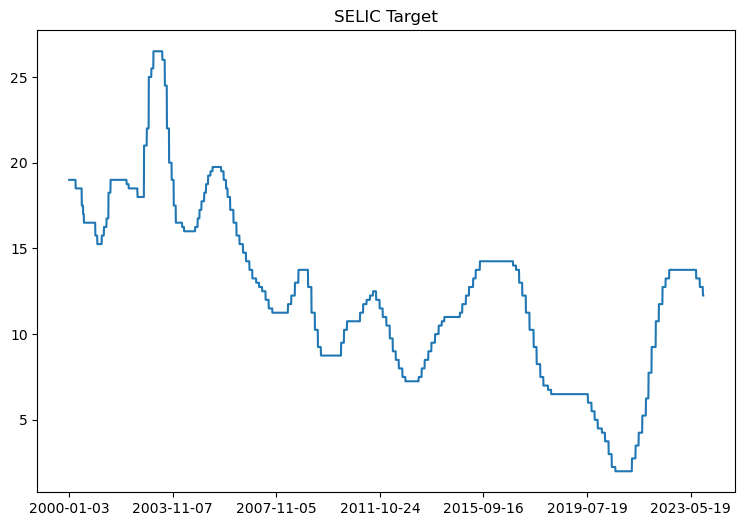

In [29]:
df_SETA['PX_LAST'].plot(figsize=(9, 6));
plt.title("SELIC Target");

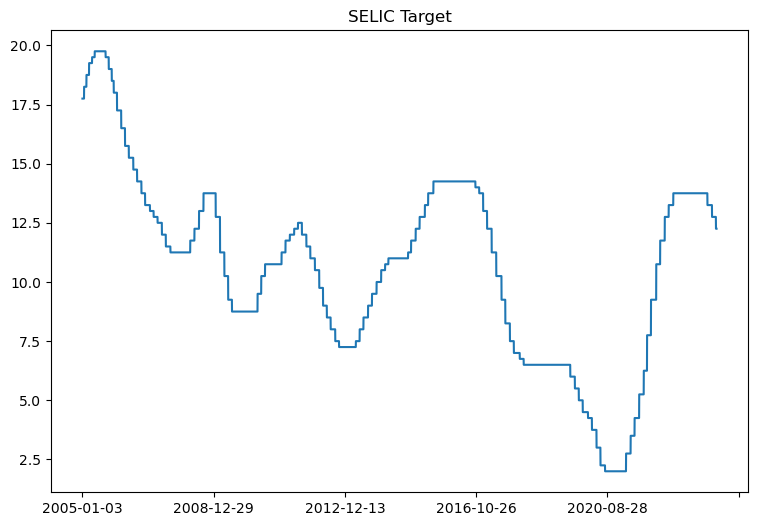

In [30]:
df_SETA['PX_LAST'].loc['2005':].plot(figsize=(9, 6));
plt.title("SELIC Target");

#### Loading DI1

In [2]:
df_DI1 = pd.read_csv('df_all_DI1.csv', index_col=0).dropna(subset=['PX_SETTLE'])

In [3]:
df_DI1

,MATURITY,PX_SETTLE,FUT_BUS_DAYS_VAL,VOLUME,RT_OPEN_INTEREST,CONTRACT,EXCH_YEST_ADJ_ALT_SETT_RATE
Date,,,,,,,
2000-01-03,0.083333,19.105,21.0,9697.0,97996.0,ODG00,NaN
2000-01-04,0.079365,19.221,20.0,49167.0,101220.0,ODG00,NaN
2000-01-05,0.075397,19.203,19.0,13235.0,131594.0,ODG00,NaN
2000-01-06,0.071429,19.138,18.0,8060.0,136199.0,ODG00,NaN
2000-01-07,0.067460,19.071,17.0,5960.0,133223.0,ODG00,NaN
...,...,...,...,...,...,...,...
2023-10-31,14.126984,11.892,3560.0,NaN,3200.0,ODF38,11.933
2023-11-01,14.123016,11.715,3559.0,NaN,3200.0,ODF38,11.892
2023-11-03,14.119048,11.505,3558.0,NaN,3200.0,ODF38,11.715


In [127]:
df_DI1_short = (df_DI1[(df_DI1['MATURITY'] <0.5)][['MATURITY', 'PX_SETTLE']]).reset_index().sort_values(['Date', 'MATURITY']).set_index(['Date', 'MATURITY'])

In [94]:
df_DI1_7p = (df_DI1[(df_DI1['MATURITY'] >= 7)][['MATURITY', 'PX_SETTLE']]).reset_index().sort_values(['Date', 'MATURITY']).set_index(['Date', 'MATURITY'])

In [95]:
df_DI1_7p

PX_SETTLE
Date       MATURITY            
2003-02-17 7.095238      39.500
2003-02-18 7.091270      40.000
2003-02-19 7.087302      40.009
2003-02-20 7.083333      40.017
2003-02-21 7.079365      40.026
...                         ...
2023-11-07 10.130952     11.438
           11.119048     11.493
           12.111111     11.459
           13.119048     11.478
           14.111111     11.478

[29909 rows x 1 columns]

In [122]:
df_DI1_7p_dates = df_DI1_7p.loc['2005':,:].index.get_level_values(0).unique()

In [123]:
df_DI1_7p_dates

Index(['2006-03-22', '2006-03-23', '2006-03-24', '2006-03-27', '2006-03-28',
       '2006-03-29', '2006-03-30', '2006-03-31', '2006-04-03', '2006-04-04',
       ...
       '2023-10-24', '2023-10-25', '2023-10-26', '2023-10-27', '2023-10-30',
       '2023-10-31', '2023-11-01', '2023-11-03', '2023-11-06', '2023-11-07'],
      dtype='object', name='Date', length=4363)

In [129]:
df_DI1_short_rates = [(df_DI1_short.loc[d].iloc[0])[0] for d in df_DI1_7p_dates]

In [130]:
df_DI1_7p_rates = [(df_DI1_7p.loc[d].iloc[0])[0] for d in df_DI1_7p_dates]

In [131]:
df_DI1_7 = pd.DataFrame({'Short': df_DI1_short_rates, '7y': df_DI1_7p_rates}, index=df_DI1_7p_dates)

In [133]:
df_DI1_7['DIFF'] = df_DI1_7['7y'] - df_DI1_7['Short']

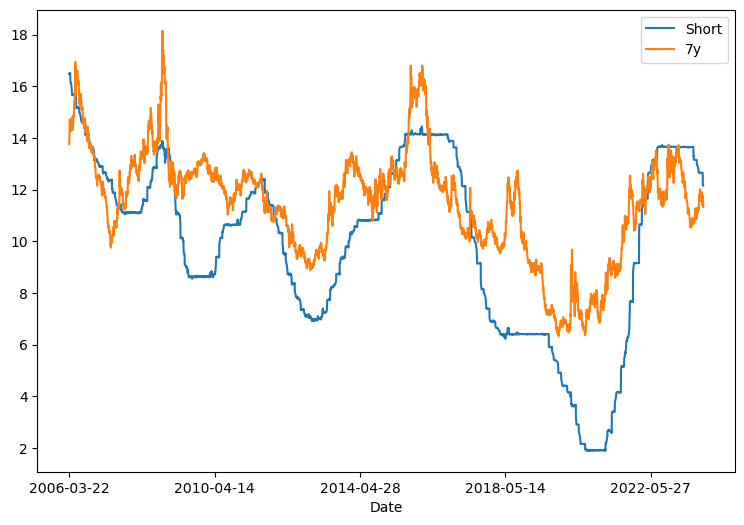

In [134]:
df_DI1_7[['Short', '7y']].plot(figsize=(9, 6));

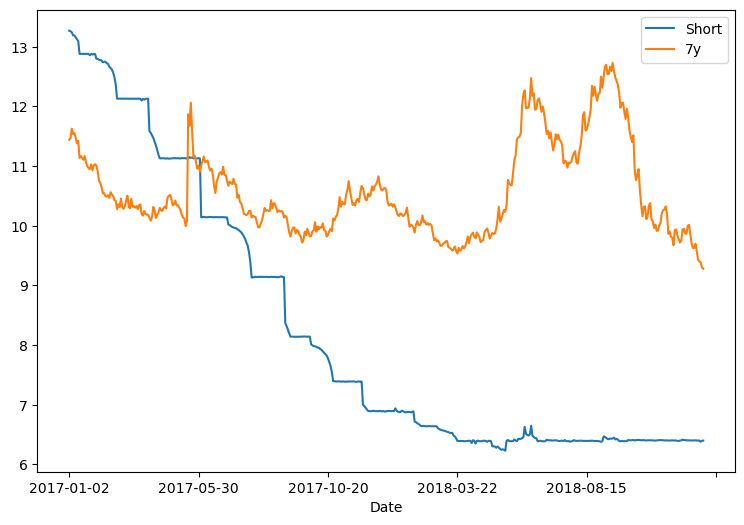

In [155]:
df_DI1_7[['Short', '7y']].loc['2017':'2019'].plot(figsize=(9, 6));

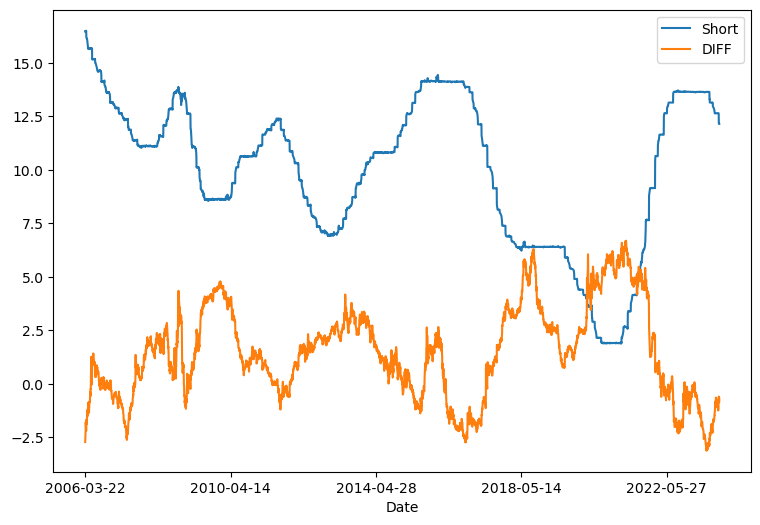

In [135]:
df_DI1_7[['Short', 'DIFF']].plot(figsize=(9, 6));

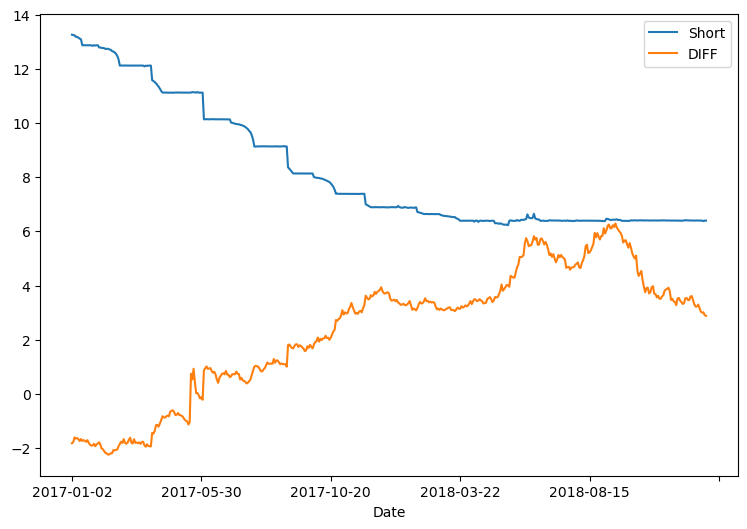

In [154]:
df_DI1_7[['Short', 'DIFF']].loc['2017':'2019'].plot(figsize=(9, 6));

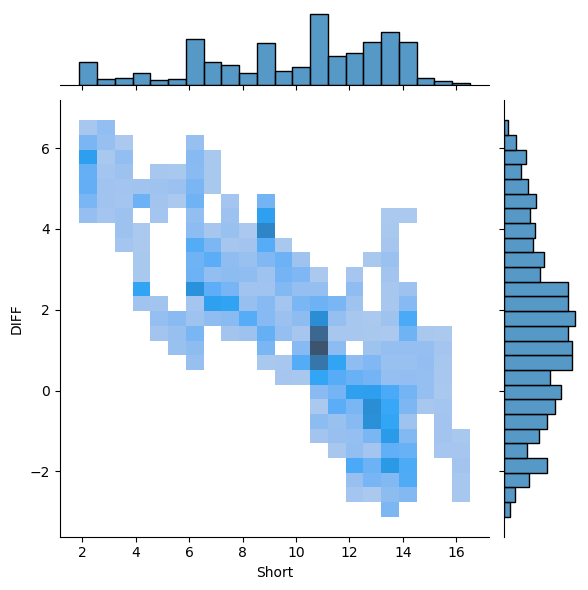

In [153]:
sns.jointplot(data=df_DI1_7, x='Short', y='DIFF', kind='hist');

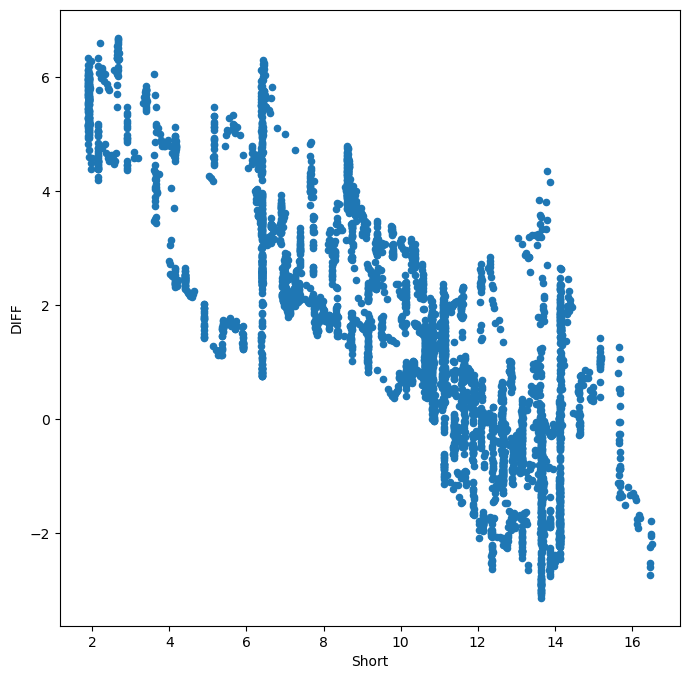

In [139]:
df_DI1_7[['Short', 'DIFF']].plot(kind='scatter', x='Short', y='DIFF', figsize=(8, 8));

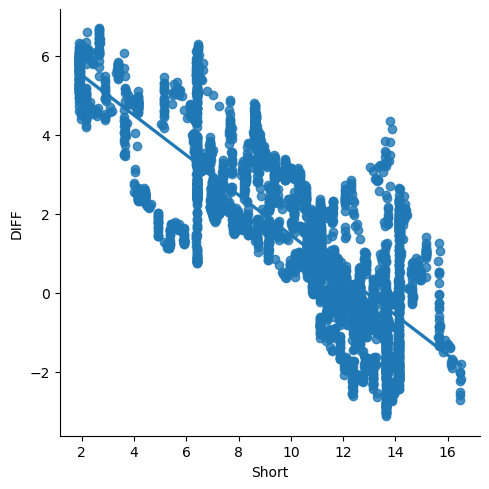

In [151]:
sns.lmplot(data=df_DI1_7, x='Short', y='DIFF');

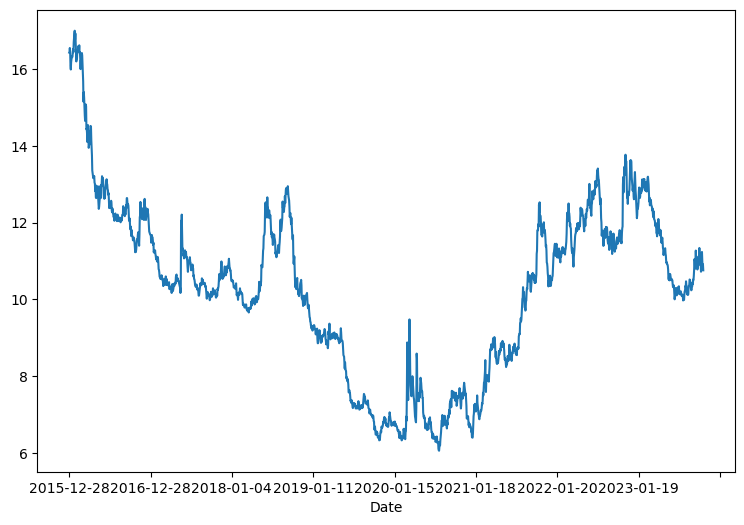

In [38]:
df_DI1[df_DI1['CONTRACT'] == 'ODF27']['PX_SETTLE'].plot(figsize=(9, 6));

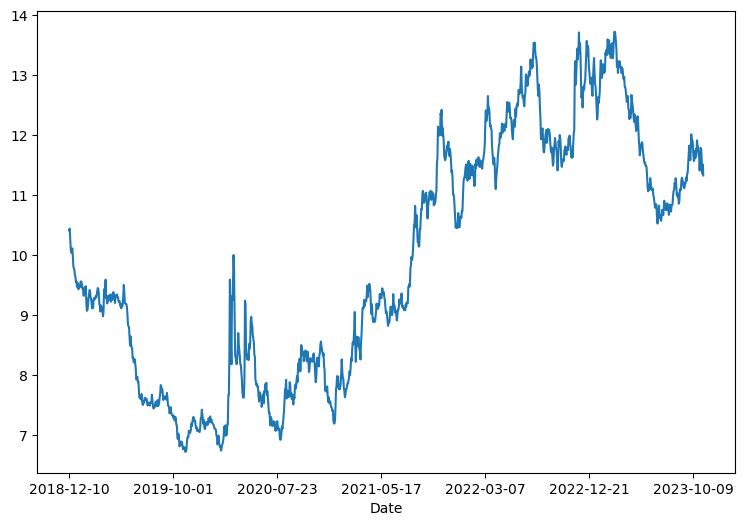

In [42]:
df_DI1[df_DI1['CONTRACT'] == 'ODF31']['PX_SETTLE'].plot(figsize=(9, 6));

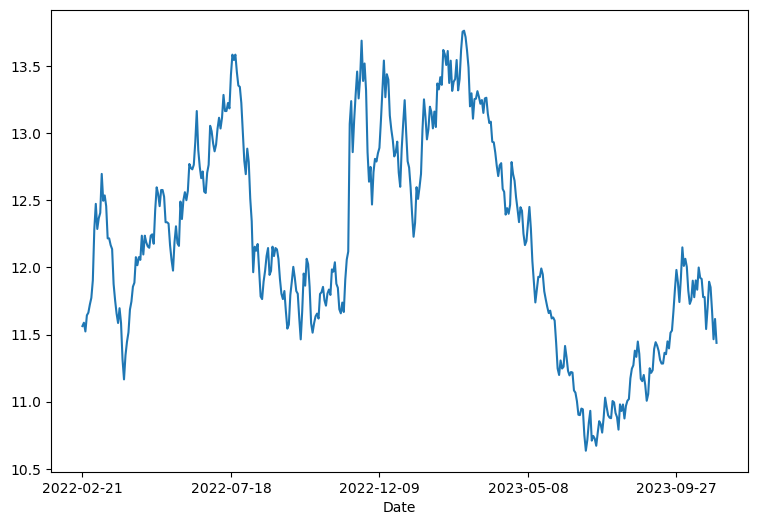

In [55]:
df_DI1[df_DI1['CONTRACT'] == 'ODF34']['PX_SETTLE'].plot(figsize=(9, 6));

In [60]:
df_DI1_2019 = df_DI1[(df_DI1['CONTRACT'] == 'ODF27') | (df_DI1['CONTRACT'] == 'ODF31') | (df_DI1['CONTRACT'] == 'ODF34')][['CONTRACT', 'PX_SETTLE']].pivot(columns=['CONTRACT']).loc['2019':]

In [61]:
df_DI1_2019.columns = ['ODF27', 'ODF31', 'ODF34']

In [62]:
df_DI1_2019

,ODF27,ODF31,ODF34
Date,,,
2019-01-02,9.320,9.550,NaN
2019-01-03,9.320,9.560,NaN
2019-01-04,9.240,9.470,NaN
2019-01-07,9.310,9.540,NaN
2019-01-08,9.240,9.470,NaN
...,...,...,...
2023-10-31,11.237,11.766,11.852
2023-11-01,11.026,11.586,11.675
2023-11-03,10.776,11.362,11.465


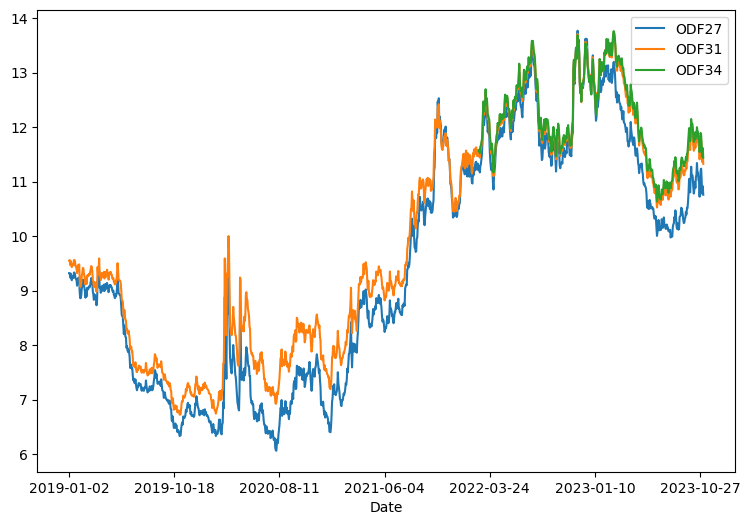

In [63]:
df_DI1_2019.plot(figsize=(9, 6));

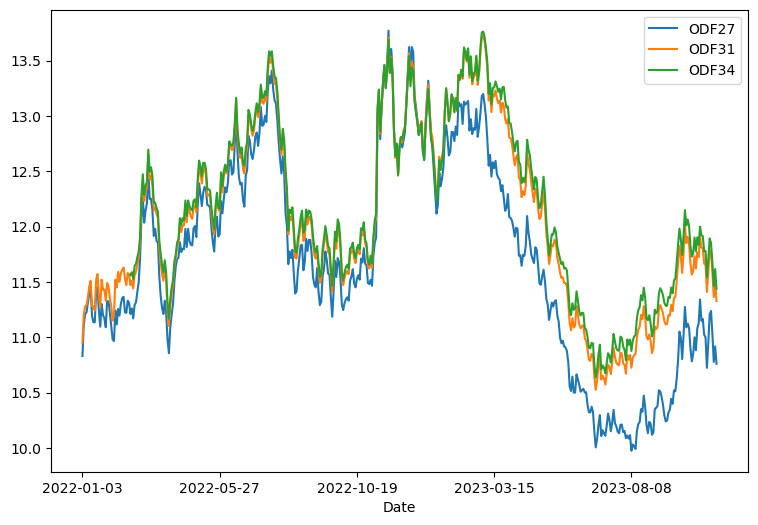

In [64]:
df_DI1_2019.loc['2022':].plot(figsize=(9, 6));

In [141]:
df_DI1_2019_diff = df_DI1_2019.copy()

In [142]:
df_DI1_2019_diff['DIFF_31_27'] = df_DI1_2019_diff['ODF31'] - df_DI1_2019_diff['ODF27']

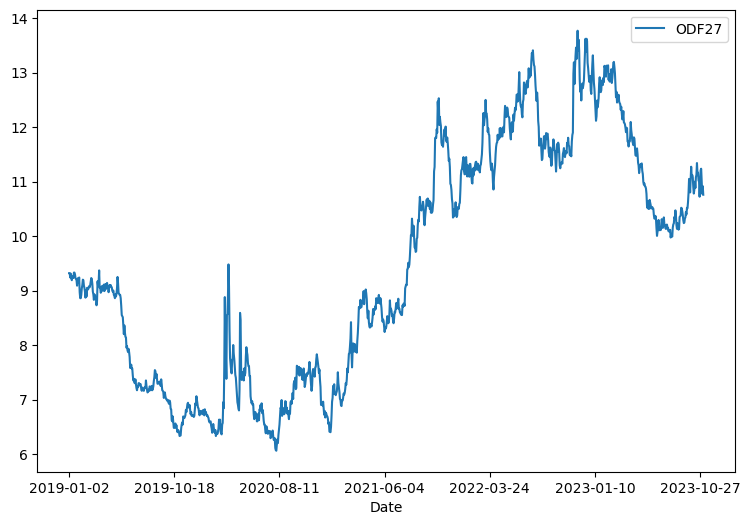

In [143]:
df_DI1_2019_diff[['ODF27']].plot(figsize=(9, 6));

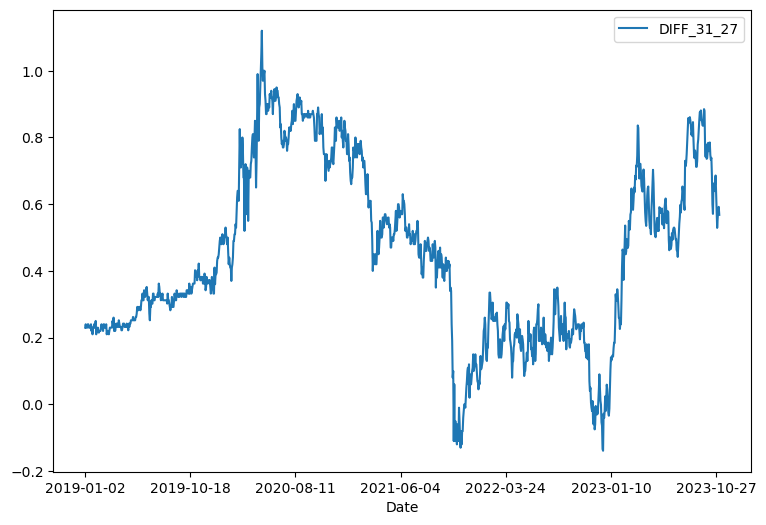

In [144]:
df_DI1_2019_diff[['DIFF_31_27']].plot(figsize=(9, 6));

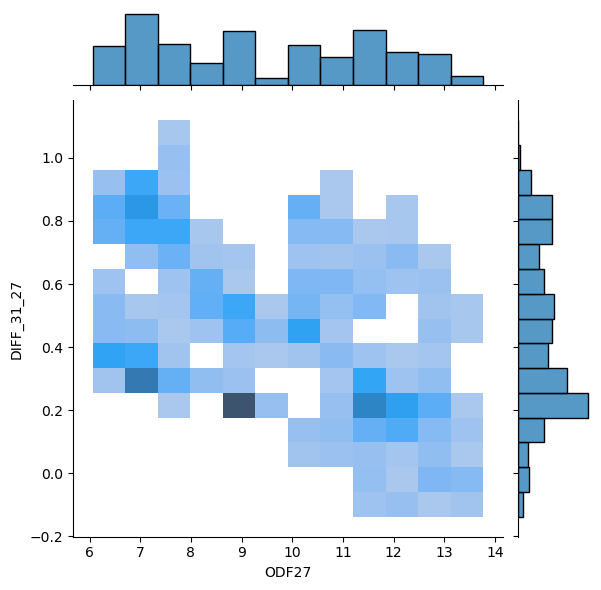

In [146]:
sns.jointplot(data=df_DI1_2019_diff[['ODF27', 'DIFF_31_27']], x='ODF27', y='DIFF_31_27', kind='hist');

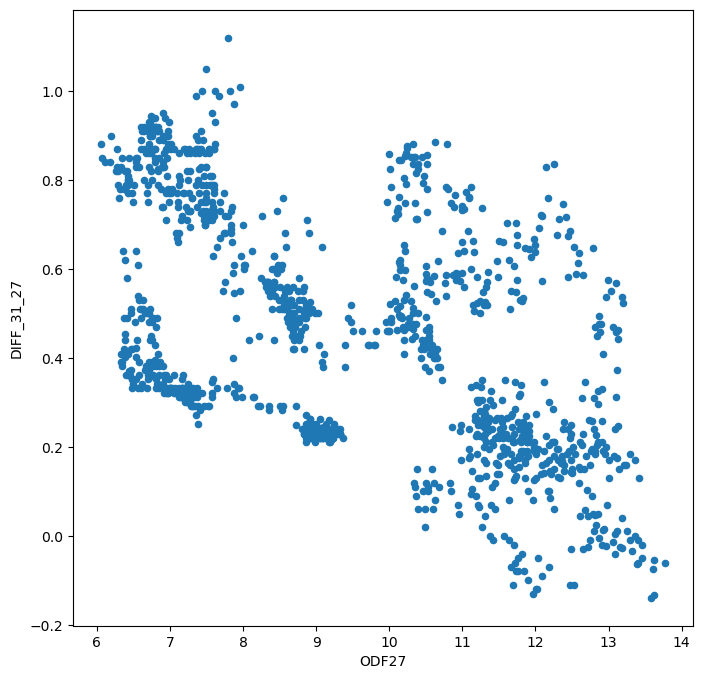

In [147]:
df_DI1_2019_diff[['ODF27', 'DIFF_31_27']].plot(kind='scatter', x='ODF27', y='DIFF_31_27', figsize=(8, 8));

#### Loading SOFR

In [33]:
SOFR_mats_10 = ['A', 'B', 'C',
                'F', 'I', '1',
                '1F',
                '2', '3', '4', '5',
                '6', '7', '8', '9', '10']

In [34]:
sofr_yrs_10 = [1/12, 2/12, 3/12,
               6/12, 9/12, 1,
               3/2,
               2, 3, 4, 5,
               6, 7, 8, 9, 10]

In [35]:
sofr_sqrt_yrs_10 = np.sqrt(sofr_yrs_10)

In [36]:
sofr_dict_sqrt_mats_10 = dict(zip(SOFR_mats_10, sofr_sqrt_yrs_10))

In [37]:
sofr_dict_sqrt_mats_10

{'A': 0.28867513459481287,
 'B': 0.408248290463863,
 'C': 0.5,
 'F': 0.7071067811865476,
 'I': 0.8660254037844386,
 '1': 1.0,
 '1F': 1.224744871391589,
 '2': 1.4142135623730951,
 '3': 1.7320508075688772,
 '4': 2.0,
 '5': 2.23606797749979,
 '6': 2.449489742783178,
 '7': 2.6457513110645907,
 '8': 2.8284271247461903,
 '9': 3.0,
 '10': 3.1622776601683795}

In [38]:
df_SOFR = pd.read_csv('df_all_SOFR_10.csv', index_col=0)

#### Loading Swpt

In [39]:
df_Swpt = pd.read_csv('df_all_Swpt_10.csv', index_col=0)

## USD Results

### Functions

In [40]:
SOFR_dates = sorted(list(set(df_SOFR.index.values)))

In [41]:
def get_sofr_str_mats(dict_mats, codes):
    return [dict_mats[str(m)] for m in list(codes)]

In [42]:
def betas_sofr_10(dict_mats, date):
    mats = get_sofr_str_mats(dict_mats, (df_SOFR.loc[date])['MATURITY'].values)
    rates = (df_SOFR.loc[date])['PX_LAST'].values
    return ir_curve_to_betas(mats, rates)

In [322]:
def sqrtt_SOFR(date):
    mats = get_sofr_str_mats(sofr_dict_sqrt_mats_10, (df_SOFR.loc[date])['MATURITY'].values)
    rates = (df_SOFR.loc[date])['PX_LAST'].values
    return pd.Series(rates, index=mats)

In [43]:
def plot_sofr_10(dict_mats, date, xlabel, ylabel):
    plt.rcParams['figure.figsize'] = [8, 5]
    plt.plot(
        get_sofr_str_mats(dict_mats, (df_SOFR.loc[date])['MATURITY'].values),
        (df_SOFR.loc[date])['PX_LAST'].values,
        marker='x');
    plt.title(date);
    plt.xlabel(xlabel);
    plt.ylabel(ylabel);

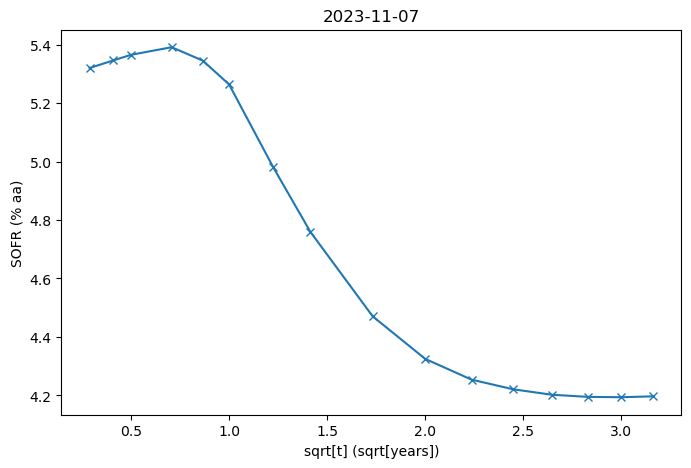

In [44]:
plot_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07', 'sqrt[t] (sqrt[years])', 'SOFR (% aa)')

In [45]:
betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')

{'r0': 5.3197,
 'betas': array([ 0.21493118,  0.2125301 ,  0.12505626, -0.28882707, -0.60832428,
        -1.2583157 , -1.16641963, -0.90958503, -0.54301339, -0.30033722,
        -0.15509196, -0.09426196, -0.0399615 , -0.00699411,  0.01848683]),
 'dts': array([0.11957316, 0.09175171, 0.20710678, 0.15891862, 0.1339746 ,
        0.22474487, 0.18946869, 0.31783725, 0.26794919, 0.23606798,
        0.21342177, 0.19626157, 0.18267581, 0.17157288, 0.16227766])}

In [46]:
np.sum(betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')['dts'])

2.8736025255735664

In [47]:
temp = betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')
get_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

{1: [2.8736025255735664, -1.1227],
 2: [-1.3761684291472744],
 3: [-0.9067181319031974, 0.6501169970740839],
 4: [-0.43831832347725147, 0.33738822247925754, -0.22766770980162201],
 5: [-0.17269287516330578,
  0.1254374124362982,
  0.1345238494958821,
  -0.10482003572901559,
  -0.059982142871430125,
  0.06222334588831411]}

In [48]:
temp = betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')
get_flat_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

[2.8736025255735664,
 -1.1227,
 -1.3761684291472744,
 -0.9067181319031974,
 0.6501169970740839,
 -0.43831832347725147,
 0.33738822247925754,
 -0.22766770980162201,
 -0.17269287516330578,
 0.1254374124362982,
 0.1345238494958821,
 -0.10482003572901559,
 -0.059982142871430125,
 0.06222334588831411]

### Results

In [49]:
%%time

SOFR_cores_dict = {}
for d in SOFR_dates:
    betas = betas_sofr_10(sofr_dict_sqrt_mats_10, d)
    new_row = get_flat_core_level5(chain_chen_ts(betas['betas'], betas['dts']))
    SOFR_cores_dict[d] = new_row
SOFR_cores_df = pd.DataFrame(SOFR_cores_dict).transpose()
SOFR_cores_df.columns = ['1', '2', '12', '112', '122', '1112', '1122', '1222', '11112', '11122', '11212', '11222', '12122', '12222']

CPU times: user 19 s, sys: 56.6 ms, total: 19.1 s
Wall time: 19.1 s


In [50]:
list(SOFR_cores_dict.keys())[-1]

'2023-11-07'

In [51]:
SOFR_cores_df

,1,2,12,112,122,1112,1122,1222,11112,11122,11212,11222,12122,12222
2007-01-31,2.873603,-0.0999,-0.054032,0.087862,0.011479,0.132725,0.009082,-0.000366,0.100590,0.005960,-0.008655,-0.000086,-0.000559,0.000017
2007-02-01,2.873603,-0.0806,-0.073649,0.038771,0.009133,0.084635,0.006287,-0.000341,0.068870,0.003407,-0.004888,-0.000153,-0.000160,0.000013
2007-02-02,2.873603,-0.1081,-0.080363,0.053421,0.012190,0.102619,0.008088,-0.000520,0.081240,0.004433,-0.006314,-0.000208,-0.000304,0.000023
2007-02-05,2.873603,-0.1361,-0.105509,0.040916,0.015526,0.099903,0.009539,-0.000796,0.082456,0.004883,-0.006736,-0.000332,-0.000342,0.000038
2007-02-06,2.873603,-0.1747,-0.144608,0.020268,0.022103,0.092615,0.012651,-0.001412,0.080570,0.005917,-0.007607,-0.000603,-0.000465,0.000078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-01,2.873603,-0.9435,-1.117092,-0.657216,0.476795,-0.260327,0.240492,-0.146322,-0.071963,0.084821,0.067634,-0.066940,-0.031427,0.034888
2023-11-02,2.873603,-1.0139,-1.310533,-0.882901,0.578589,-0.434604,0.309367,-0.189206,-0.174482,0.117237,0.124491,-0.090505,-0.047662,0.048270
2023-11-03,2.873603,-1.1002,-1.258078,-0.756667,0.591320,-0.321090,0.290838,-0.203028,-0.104011,0.101957,0.095951,-0.089058,-0.049281,0.054300
2023-11-06,2.873603,-1.0392,-1.251167,-0.790538,0.559521,-0.357830,0.286320,-0.183542,-0.128029,0.103971,0.101905,-0.084049,-0.044995,0.046890


In [52]:
df_SOFR[df_SOFR['MATURITY'] == 'A'][['PX_LAST']]

,PX_LAST
Date,
2007-01-31,5.2916
2007-02-01,5.2946
2007-02-02,5.2946
2007-02-05,5.2946
2007-02-06,5.2946
...,...
2023-11-01,5.3219
2023-11-02,5.3204
2023-11-03,5.3200


In [53]:
SOFR_cores_df[['2']]

,2
2007-01-31,-0.0999
2007-02-01,-0.0806
2007-02-02,-0.1081
2007-02-05,-0.1361
2007-02-06,-0.1747
...,...
2023-11-01,-0.9435
2023-11-02,-1.0139
2023-11-03,-1.1002
2023-11-06,-1.0392


In [54]:
df_level_slope_SOFR = pd.concat([
    df_SOFR[df_SOFR['MATURITY'] == 'A'][['PX_LAST']], 
    SOFR_cores_df[['2']]],
                               axis=1)

In [55]:
df_level_slope_SOFR.sort_index(inplace=True)
df_level_slope_SOFR.columns = ['SOFR_1m', '2']

In [56]:
df_level_slope_SOFR

,SOFR_1m,2
2007-01-31,5.2916,-0.0999
2007-02-01,5.2946,-0.0806
2007-02-02,5.2946,-0.1081
2007-02-05,5.2946,-0.1361
2007-02-06,5.2946,-0.1747
...,...,...
2023-11-01,5.3219,-0.9435
2023-11-02,5.3204,-1.0139
2023-11-03,5.3200,-1.1002
2023-11-06,5.3186,-1.0392


### Charts

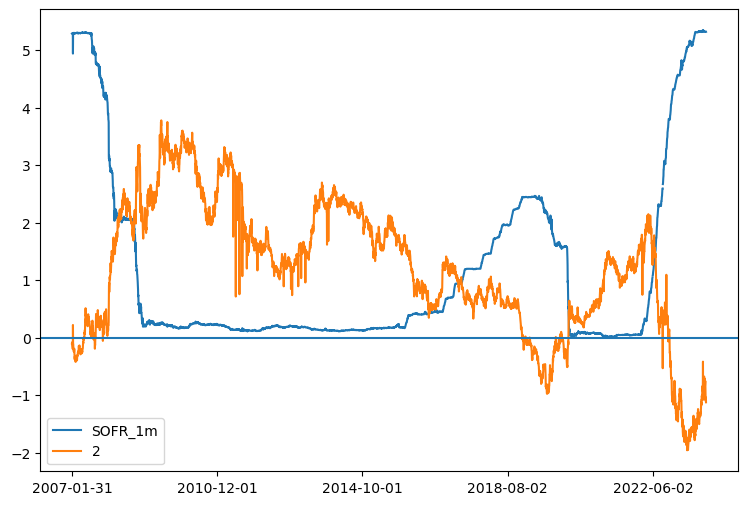

In [57]:
df_level_slope_SOFR.plot(figsize=(9, 6));
plt.axhline();

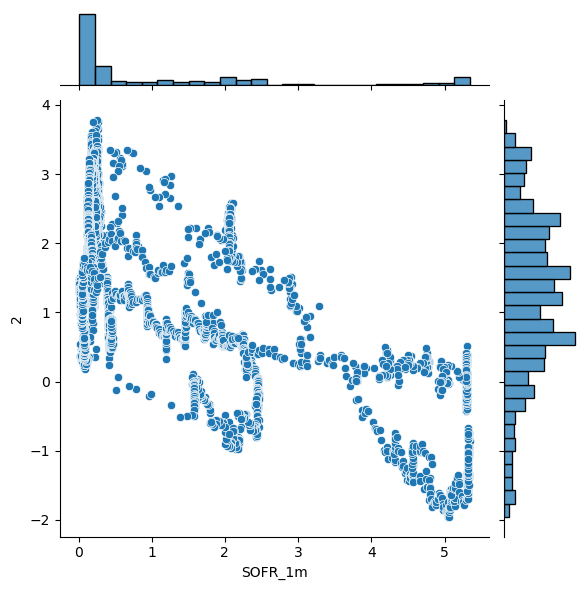

In [58]:
sns.jointplot(data=df_level_slope_SOFR, x='SOFR_1m', y='2');

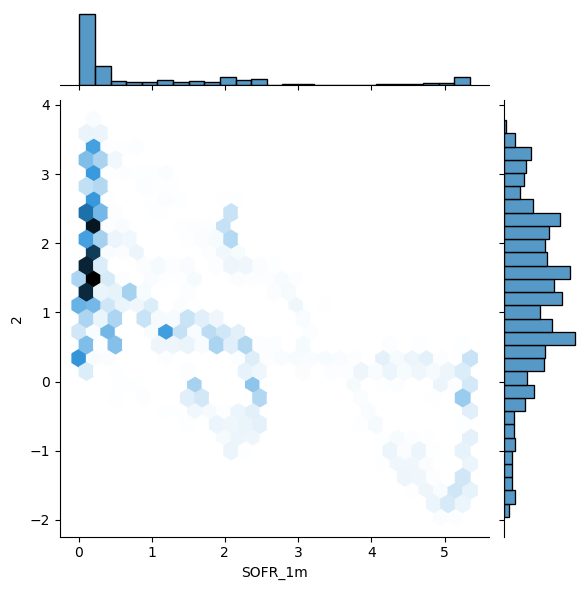

In [59]:
sns.jointplot(data=df_level_slope_SOFR, x='SOFR_1m', y='2', kind='hex');

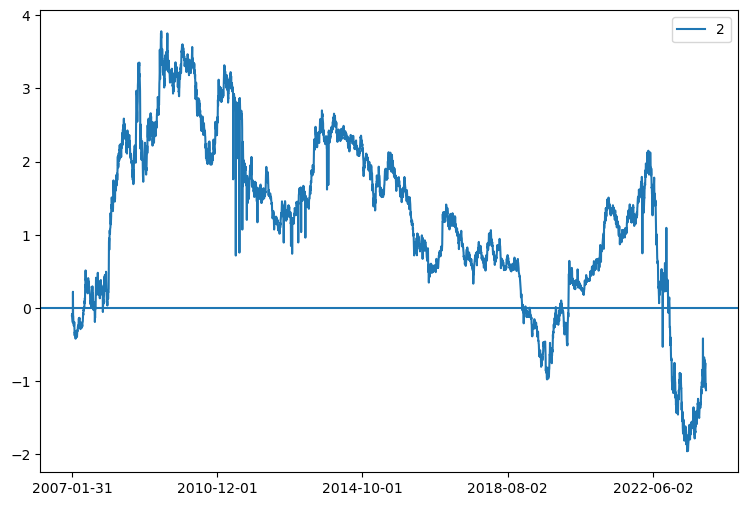

In [60]:
SOFR_cores_df[['2']].plot(figsize=(9, 6));
plt.axhline();

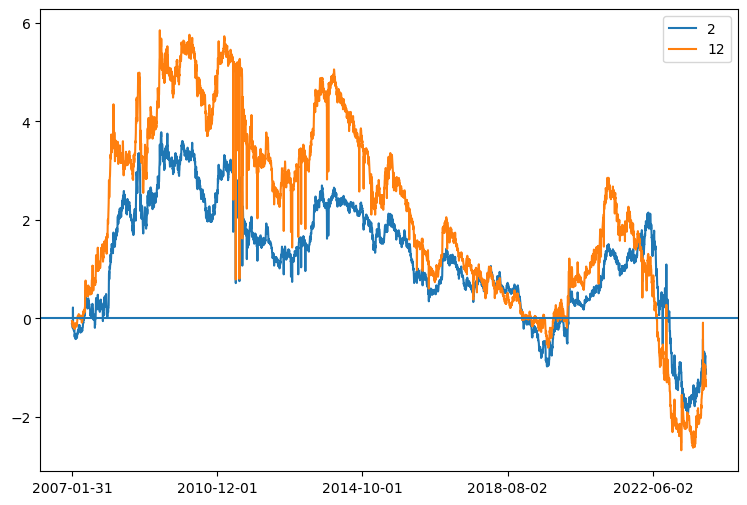

In [61]:
SOFR_cores_df[['2', '12']].plot(figsize=(9, 6));
plt.axhline();

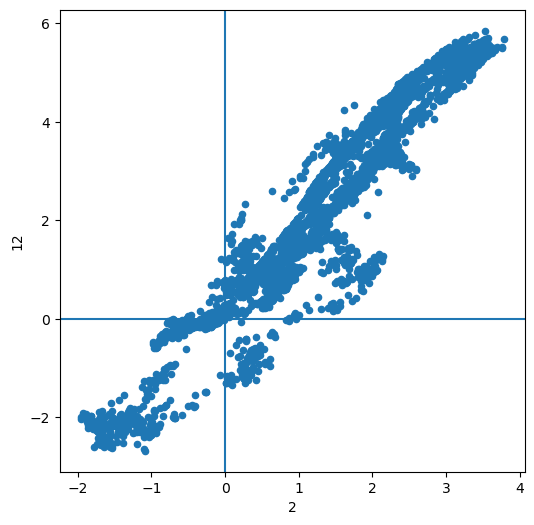

In [62]:
SOFR_cores_df.plot(kind='scatter', x='2', y='12', figsize=(6, 6));
plt.axhline();
plt.axvline();

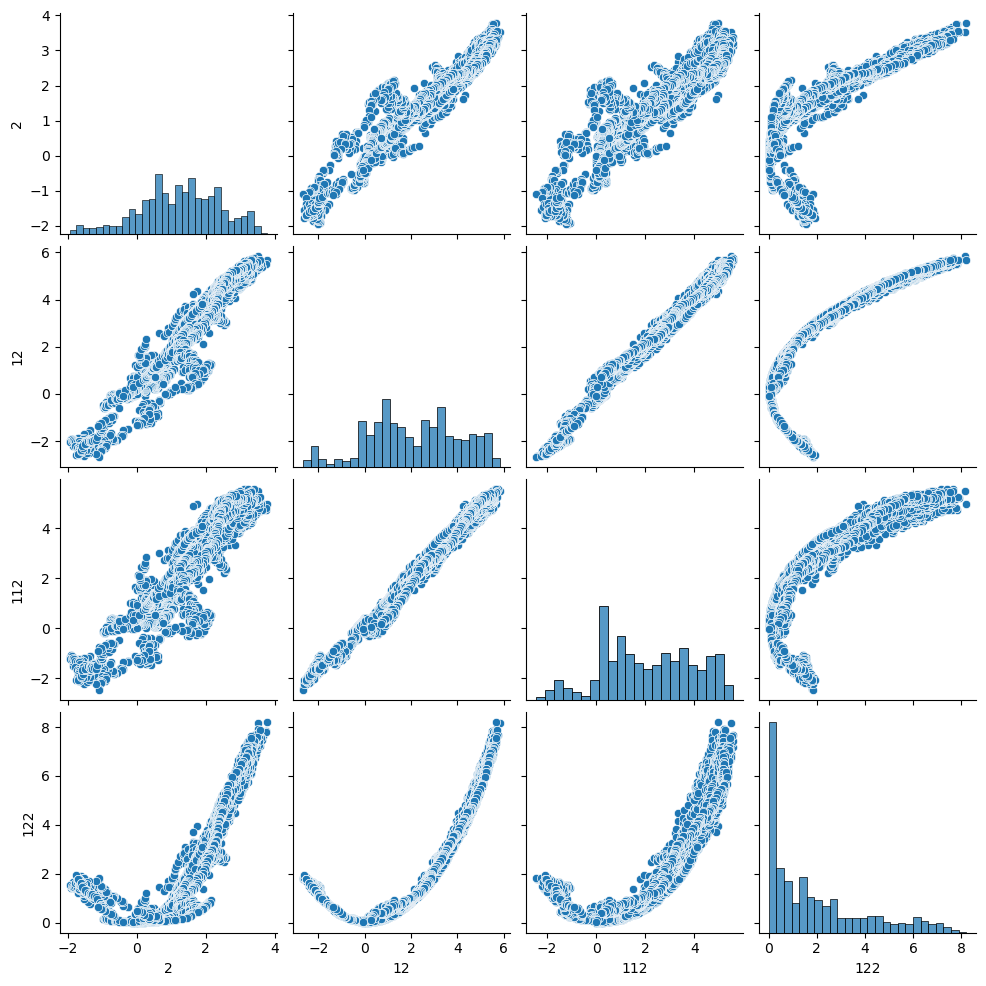

In [63]:
sns.pairplot(SOFR_cores_df[['2', '12', '112', '122',]]);

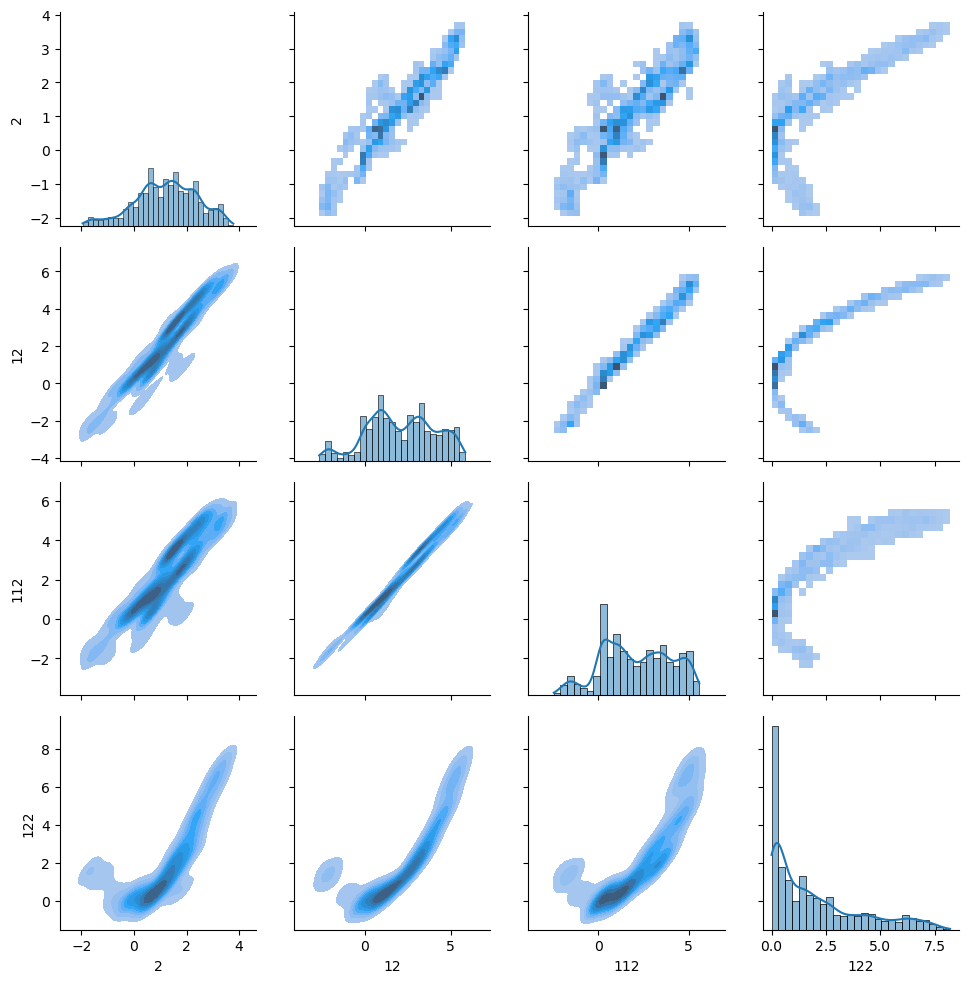

In [64]:
g = sns.PairGrid(SOFR_cores_df[['2', '12', '112', '122',]]);
g.map_upper(sns.histplot);
g.map_lower(sns.kdeplot, fill=True);
g.map_diag(sns.histplot, kde=True);

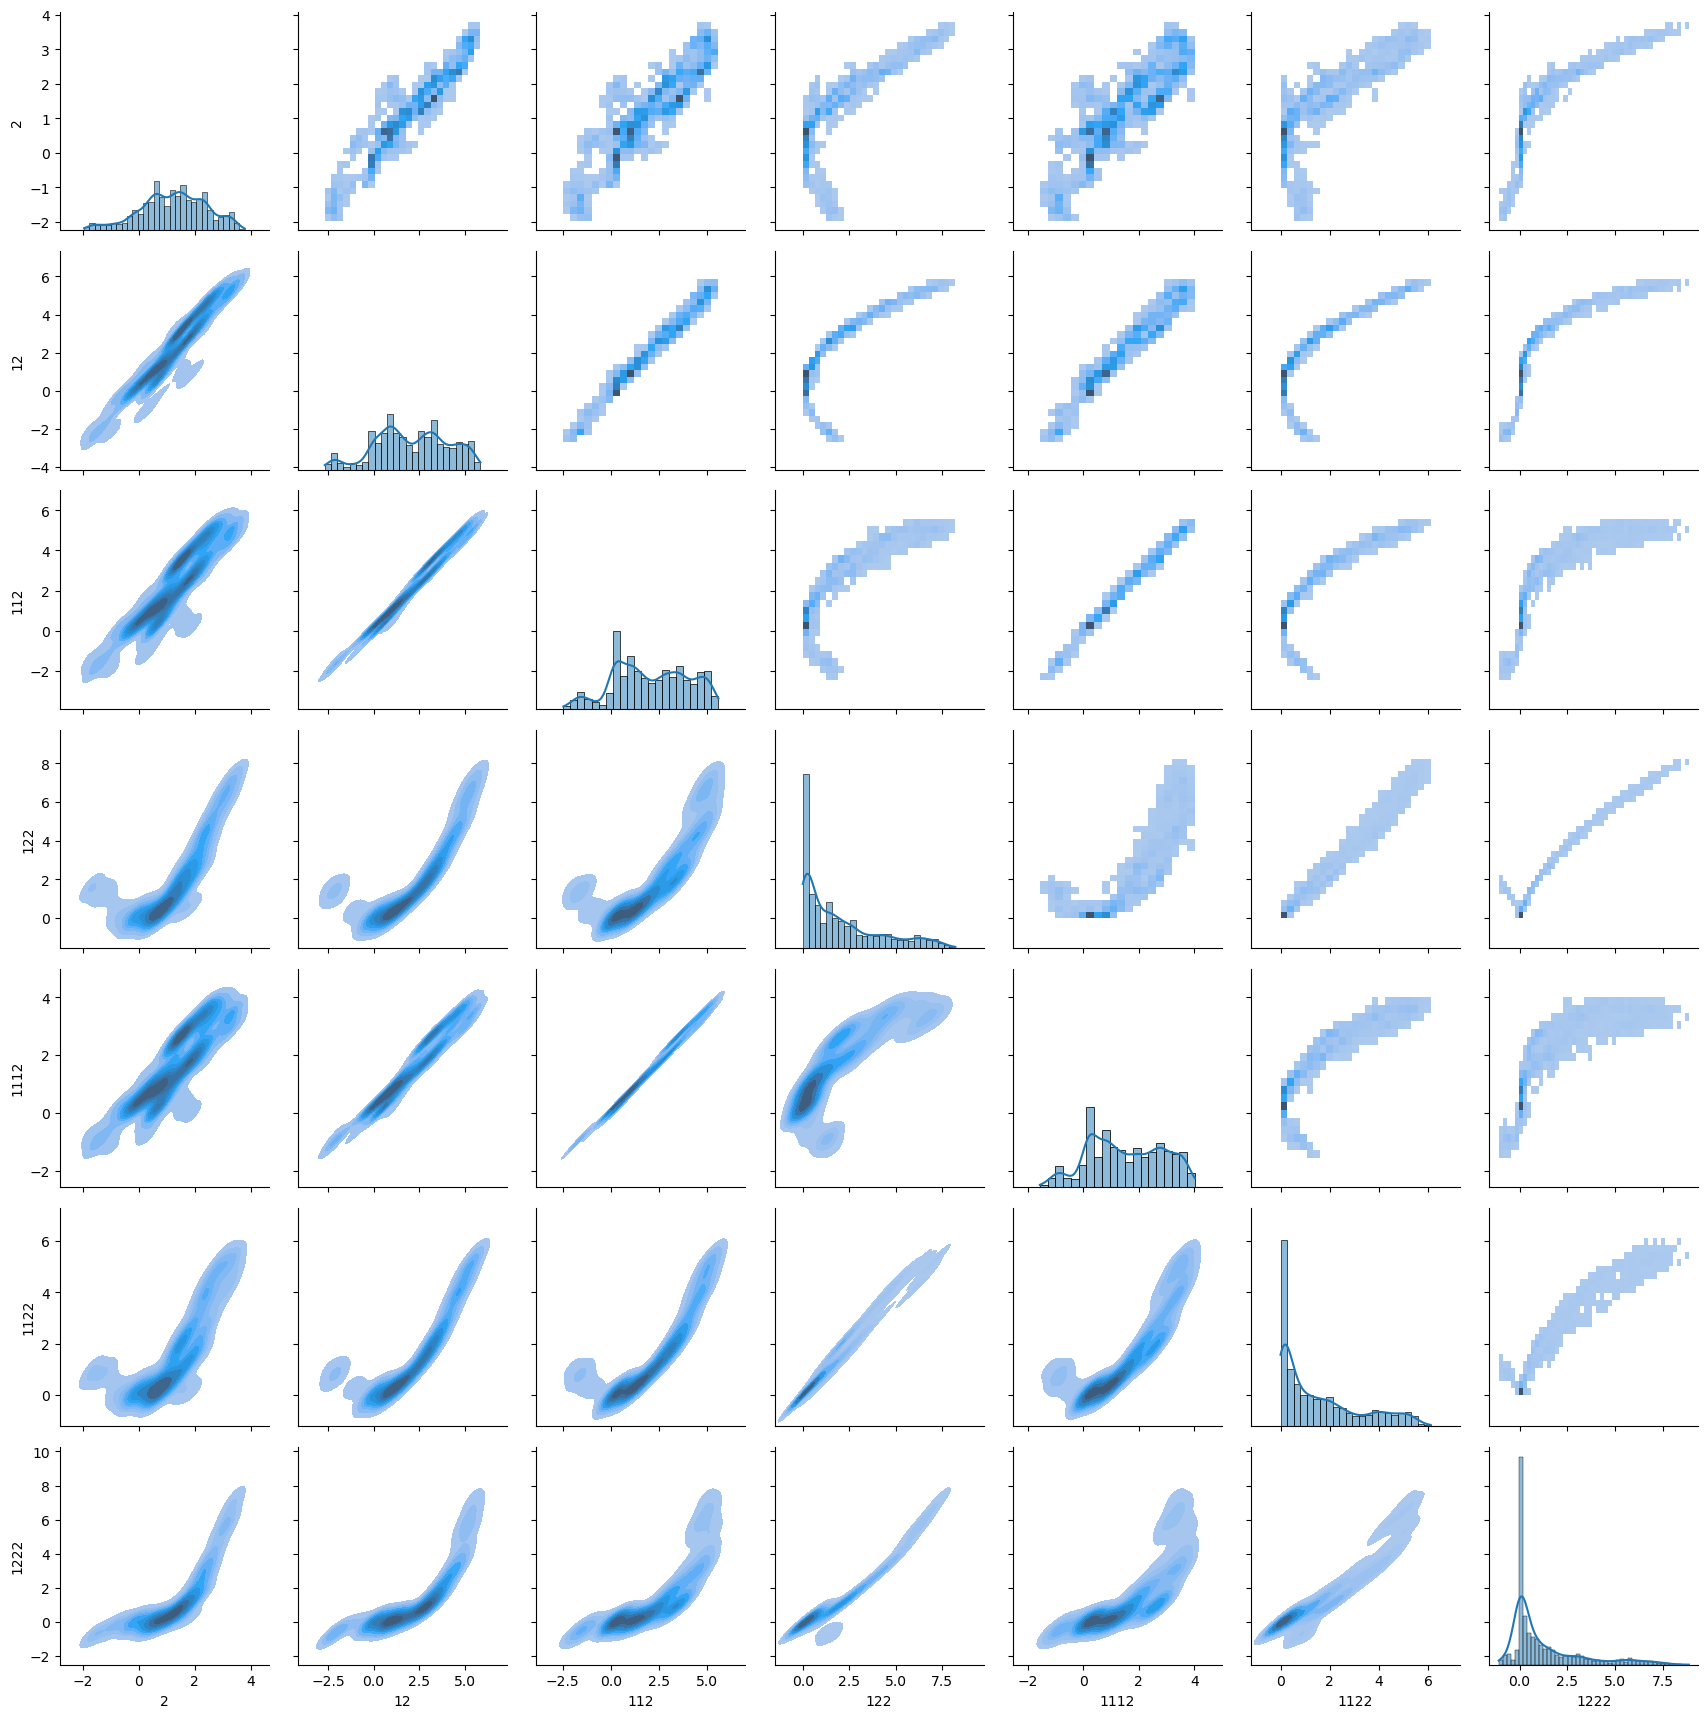

In [65]:
g = sns.PairGrid(SOFR_cores_df[['2', '12', '112', '122', '1112', '1122', '1222']]);
g.map_upper(sns.histplot);
g.map_lower(sns.kdeplot, fill=True);
g.map_diag(sns.histplot, kde=True);

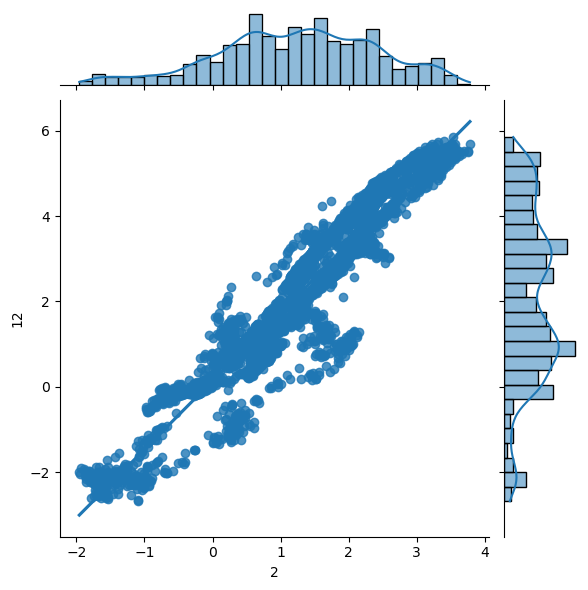

In [66]:
sns.jointplot(data=SOFR_cores_df[['2', '12', '112', '122',]], x='2', y='12', kind='reg');

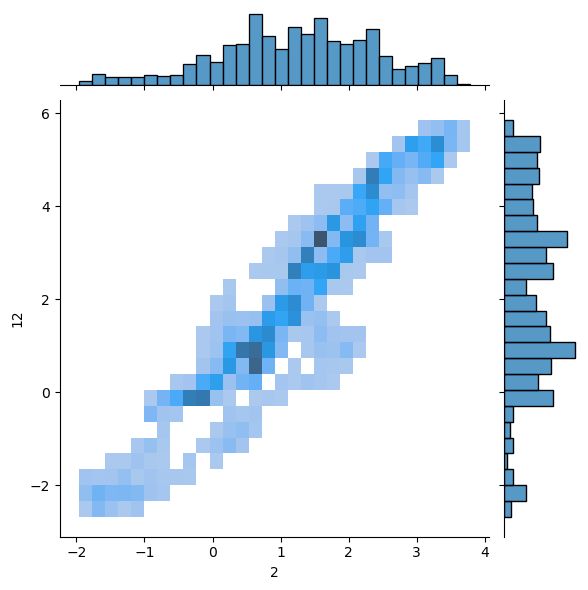

In [67]:
sns.jointplot(data=SOFR_cores_df[['2', '12', '112', '122',]], x='2', y='12', kind='hist');

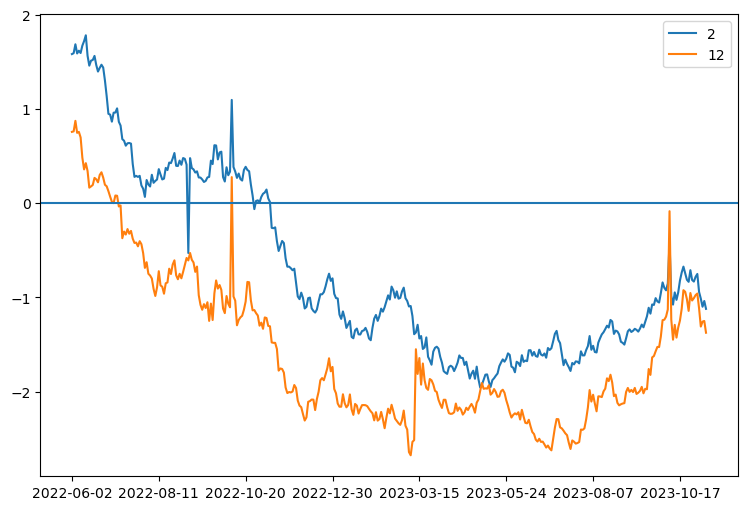

In [68]:
SOFR_cores_df[['2', '12']].loc['2022-06-02':].plot(figsize=(9, 6));
plt.axhline();

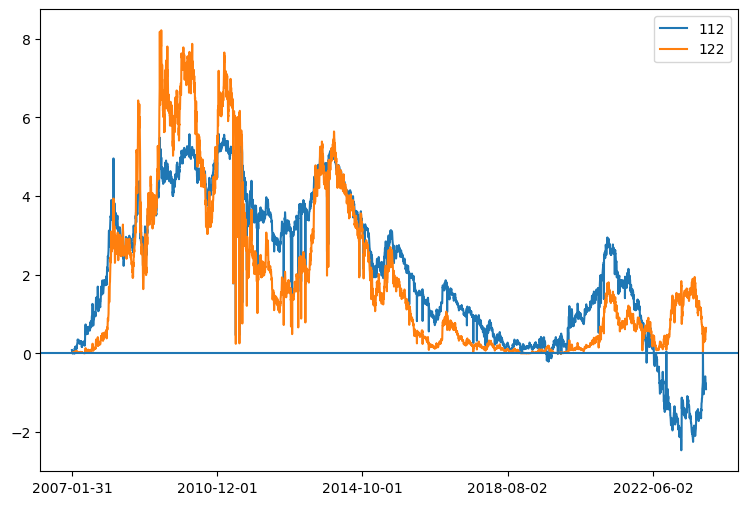

In [69]:
SOFR_cores_df[['112', '122']].plot(figsize=(9, 6));
plt.axhline();

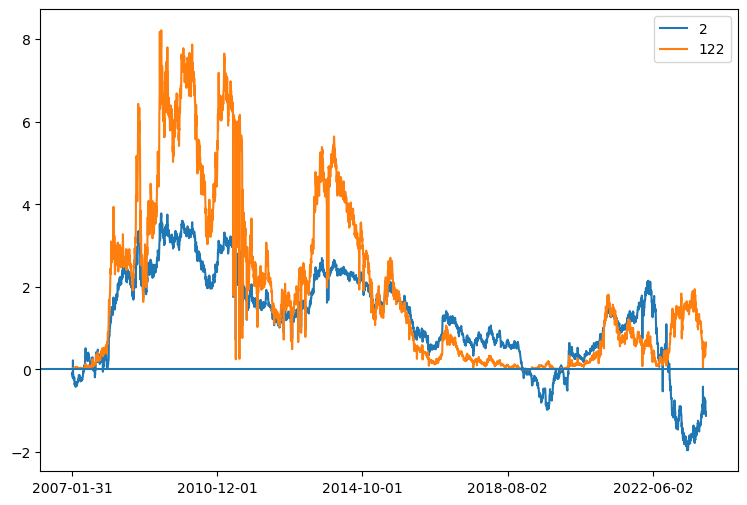

In [70]:
SOFR_cores_df[['2', '122']].plot(figsize=(9, 6));
plt.axhline();

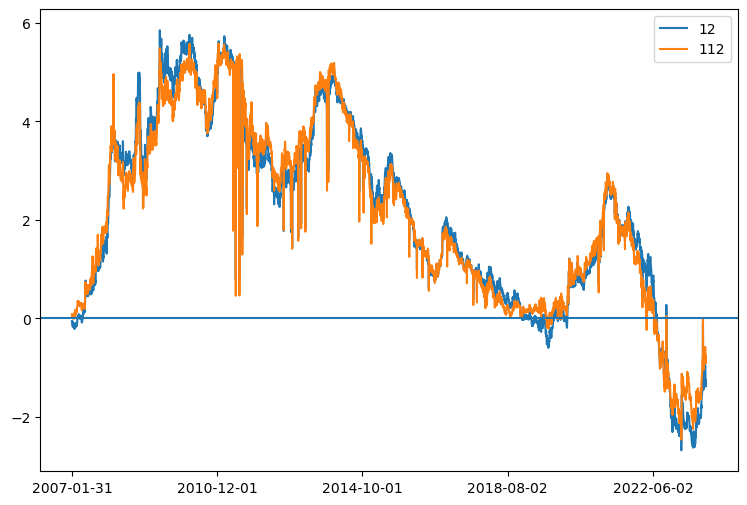

In [71]:
SOFR_cores_df[['12', '112']].plot(figsize=(9, 6));
plt.axhline();

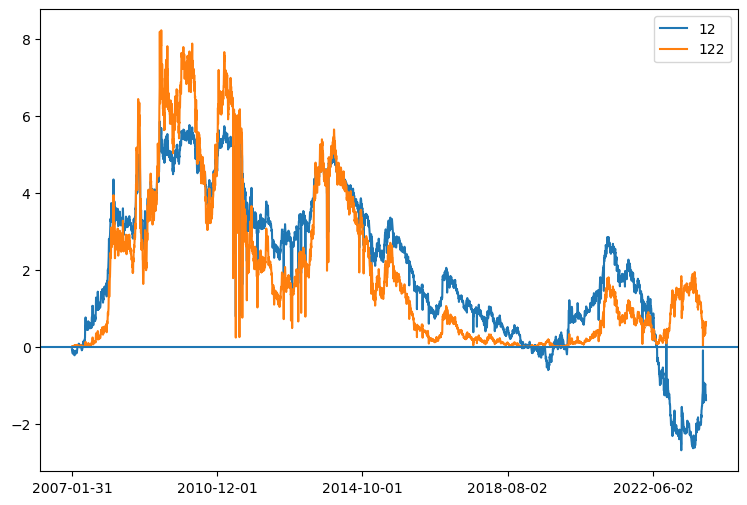

In [72]:
SOFR_cores_df[['12', '122']].plot(figsize=(9, 6));
plt.axhline();

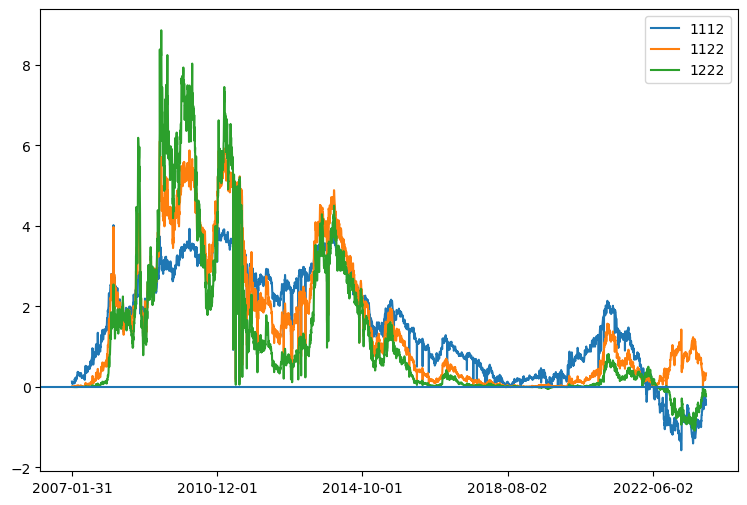

In [73]:
SOFR_cores_df[['1112', '1122', '1222']].plot(figsize=(9, 6));
plt.axhline();

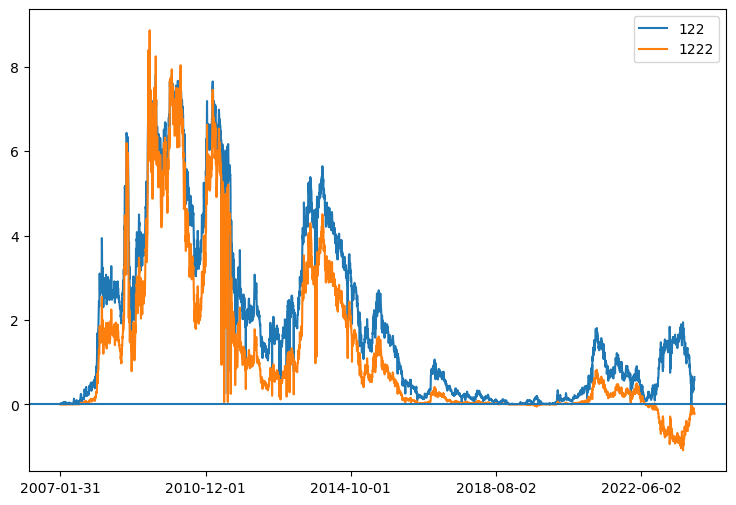

In [74]:
SOFR_cores_df[['122', '1222']].plot(figsize=(9, 6));
plt.axhline();

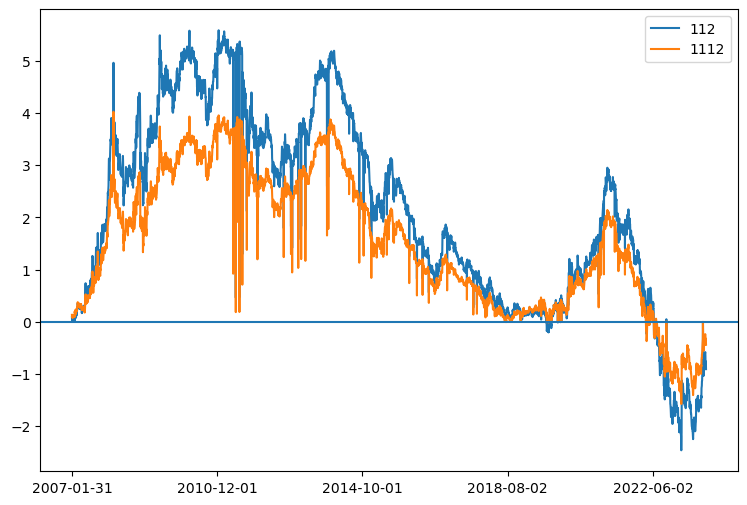

In [75]:
SOFR_cores_df[['112', '1112']].plot(figsize=(9, 6));
plt.axhline();

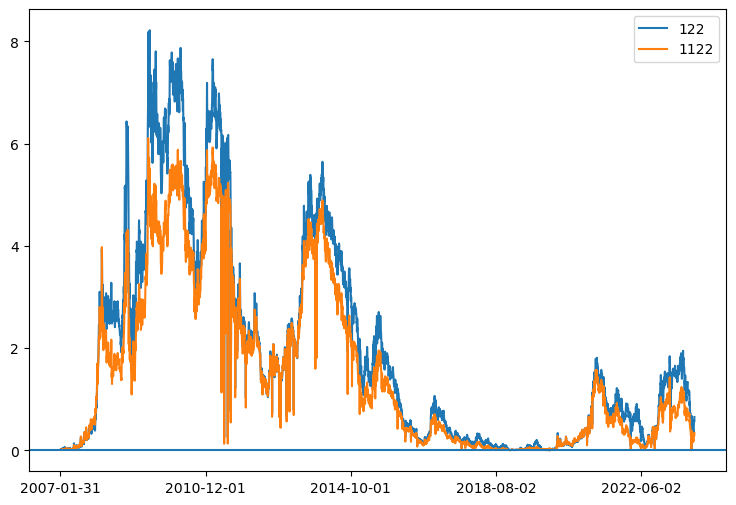

In [76]:
SOFR_cores_df[['122', '1122']].plot(figsize=(9, 6));
plt.axhline();

## BRL Results

### Functions

In [77]:
DI1_dates = sorted(list(set(df_DI1.index.values)))

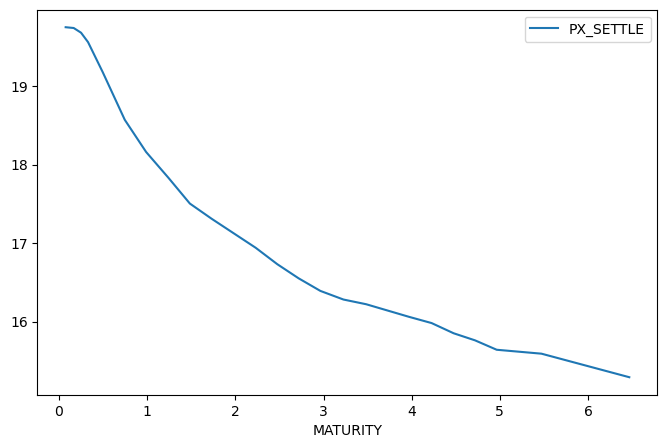

In [78]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2005-07-05'].set_index('MATURITY').plot();

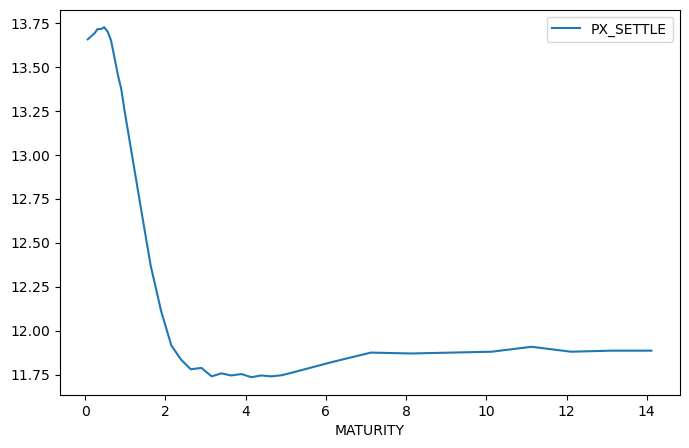

In [79]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2022-11-07'].set_index('MATURITY').plot();

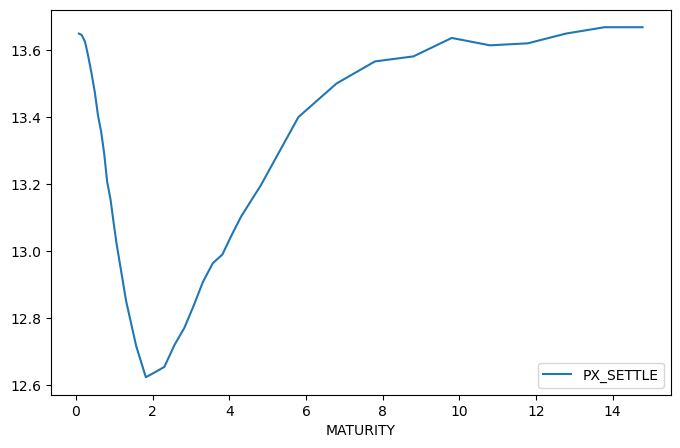

In [80]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2023-03-07'].set_index('MATURITY').plot();

In [81]:
def sqrtt_DI1(date):
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    return pd.Series(rates, index=mats)

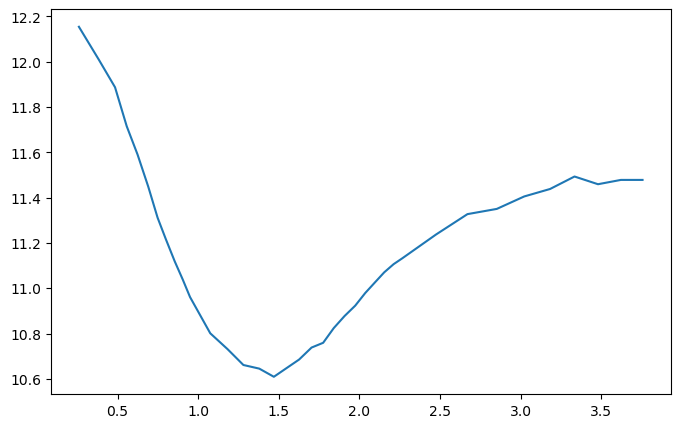

In [82]:
sqrtt_DI1('2023-11-07').plot();

In [83]:
def betas_DI1(date):
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    return ir_curve_to_betas(mats, rates)

In [84]:
betas_DI1('2023-11-07')

{'r0': 12.154,
 'betas': array([-1.17459522, -1.21165559, -2.37300493, -1.85843417, -2.1367523 ,
        -2.36420155, -1.85214024, -1.77574818, -1.6115431 , -1.71239063,
        -1.27493099, -0.65252736, -0.71198066, -0.16243362, -0.39748682,
         0.48635892,  0.48532737,  0.68400356,  0.29217041,  0.9871519 ,
         0.79467791,  0.69224304,  0.8983326 ,  0.77704844,  0.77264617,
         0.6188505 ,  0.48098304,  0.50182034,  0.46127883,  0.12651689,
         0.32310197,  0.20559136,  0.36277795, -0.23355085,  0.13387785,
         0.        ]),
 'dts': array([0.12344678, 0.10068868, 0.07248194, 0.06726092, 0.06645599,
        0.05794768, 0.05129201, 0.05518801, 0.04964186, 0.04496638,
        0.12549699, 0.1072752 , 0.09831728, 0.09850177, 0.09056904,
        0.08018769, 0.0762372 , 0.07748498, 0.07187586, 0.065846  ,
        0.06669369, 0.06645065, 0.06233771, 0.06048529, 0.05694715,
        0.05817237, 0.05405596, 0.20923823, 0.19510976, 0.18179391,
        0.1702249 , 0.16051

In [85]:
temp = betas_DI1('2023-11-07')
get_flat_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

[3.4967446490368888,
 -0.6760000000000002,
 0.9522645910569807,
 1.5261326565968316,
 0.37858791497081284,
 1.2340733371711397,
 0.4386982499139978,
 0.07182487914487903,
 0.7370510017773536,
 0.30348663527114916,
 0.045219086495485526,
 0.09646200086024719,
 -0.17701032187800386,
 0.015432342564132763]

### Results

In [86]:
%%time

DI1_cores_dict = {}
for d in DI1_dates:
    betas = betas_DI1(d)
    new_row = get_flat_core_level5(chain_chen_ts(betas['betas'], betas['dts']))
    DI1_cores_dict[d] = new_row
DI1_cores_df = pd.DataFrame(DI1_cores_dict).transpose()
DI1_cores_df.columns = ['1', '2', '12', '112', '122', '1112', '1122', '1222', '11112', '11122', '11212', '11222', '12122', '12222']

CPU times: user 59 s, sys: 121 ms, total: 59.1 s
Wall time: 59.1 s


### Charts

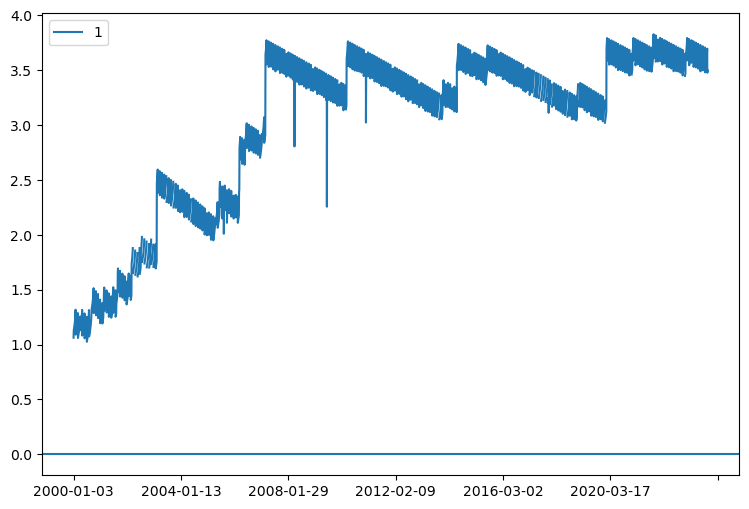

In [87]:
DI1_cores_df[['1']].plot(figsize=(9, 6));
plt.axhline();

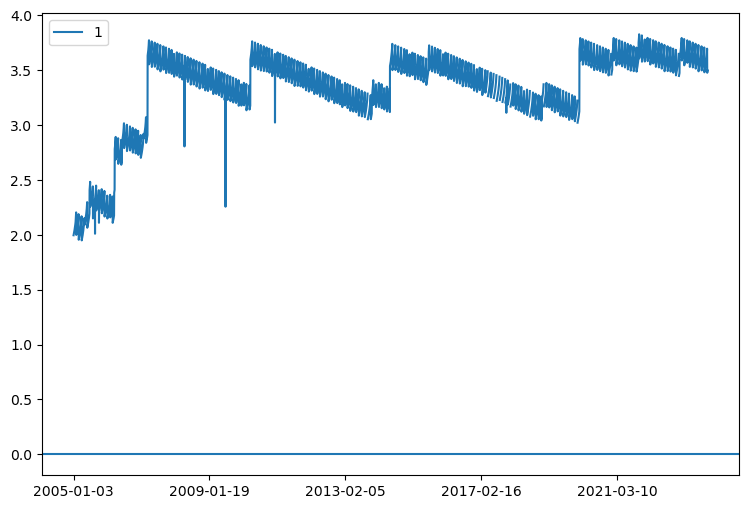

In [88]:
DI1_cores_df[['1']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

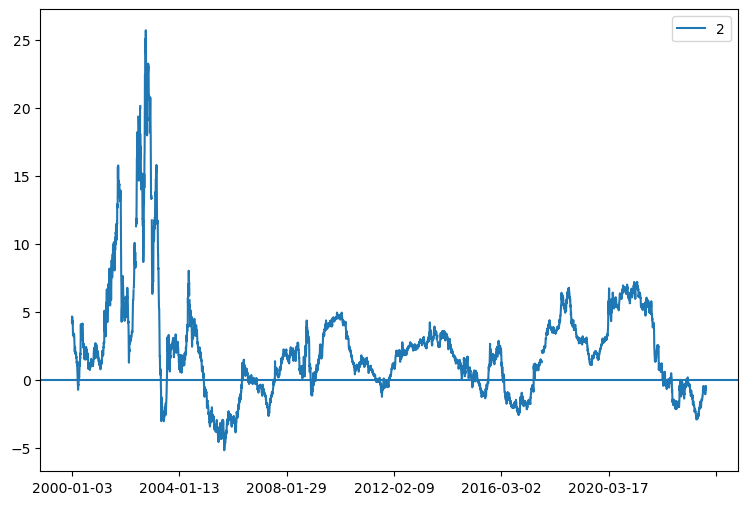

In [89]:
DI1_cores_df[['2']].plot(figsize=(9, 6));
plt.axhline();

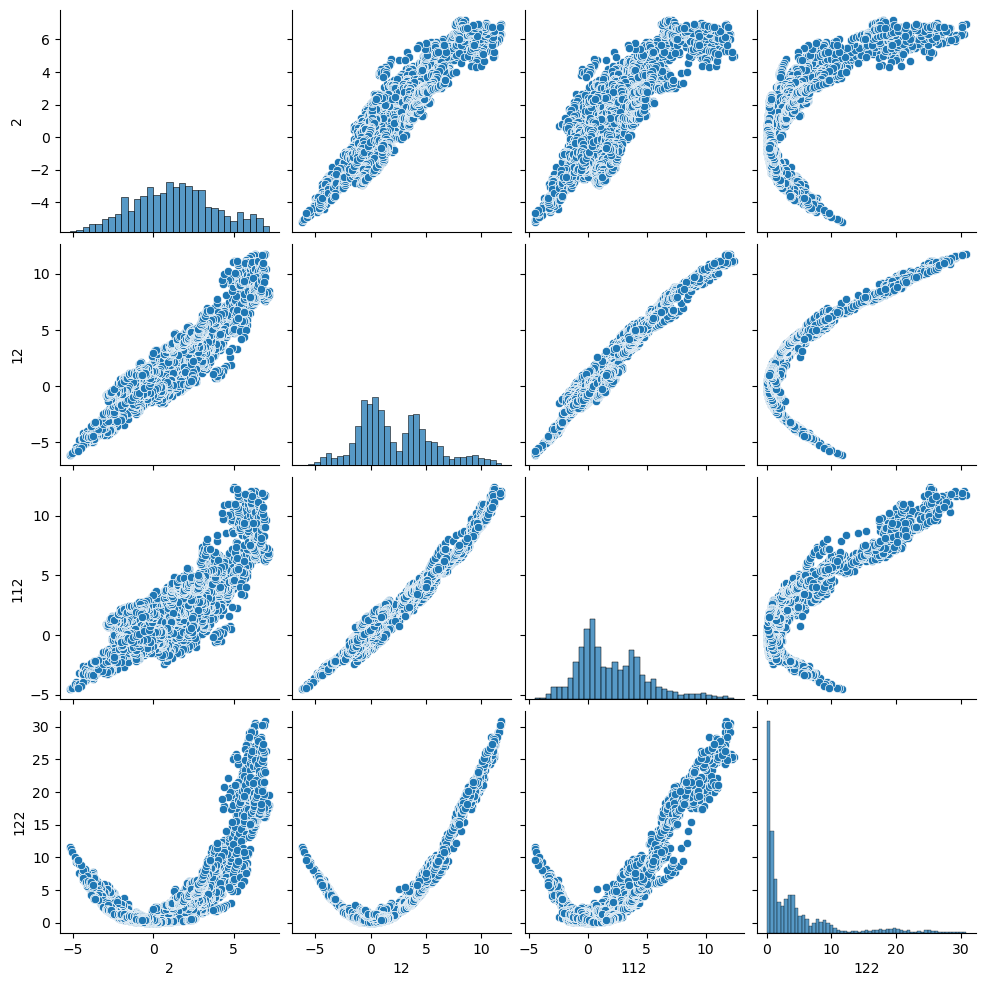

In [90]:
sns.pairplot(DI1_cores_df[['2', '12', '112', '122',]].loc['2005':]);

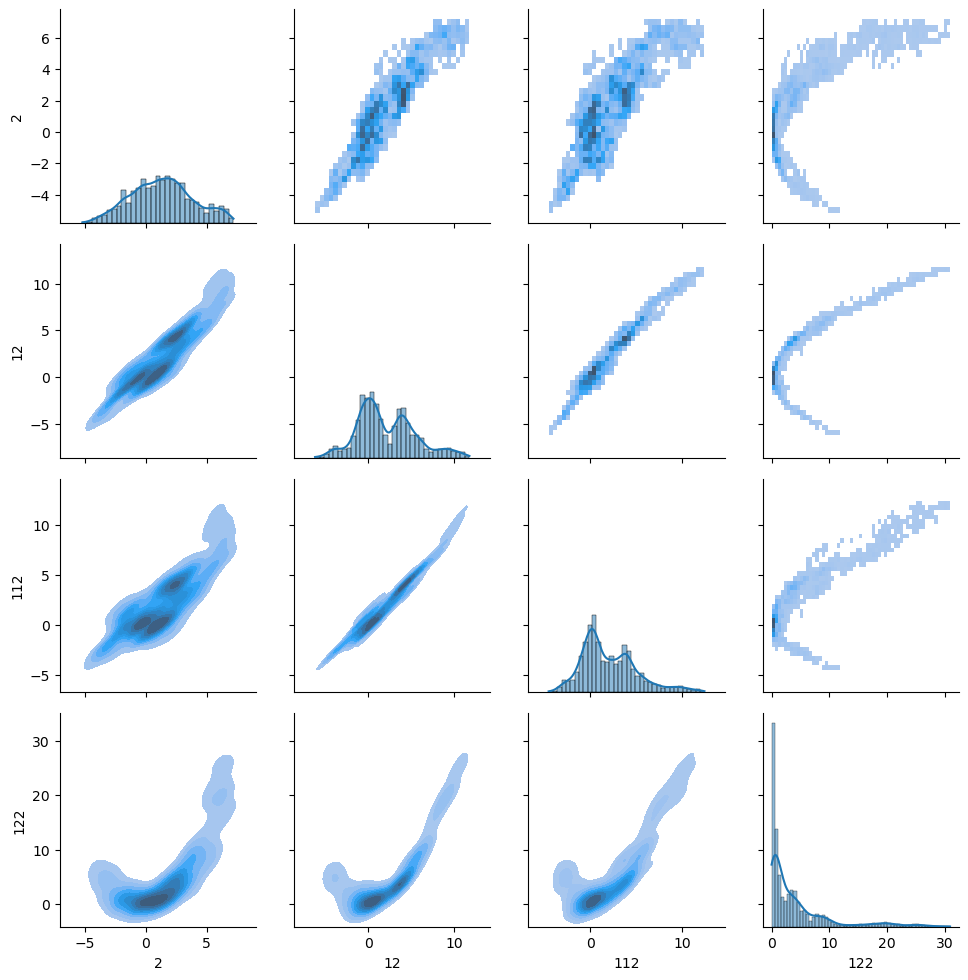

In [91]:
g2 = sns.PairGrid(DI1_cores_df[['2', '12', '112', '122',]].loc['2005':]);
g2.map_upper(sns.histplot);
g2.map_lower(sns.kdeplot, fill=True);
g2.map_diag(sns.histplot, kde=True);

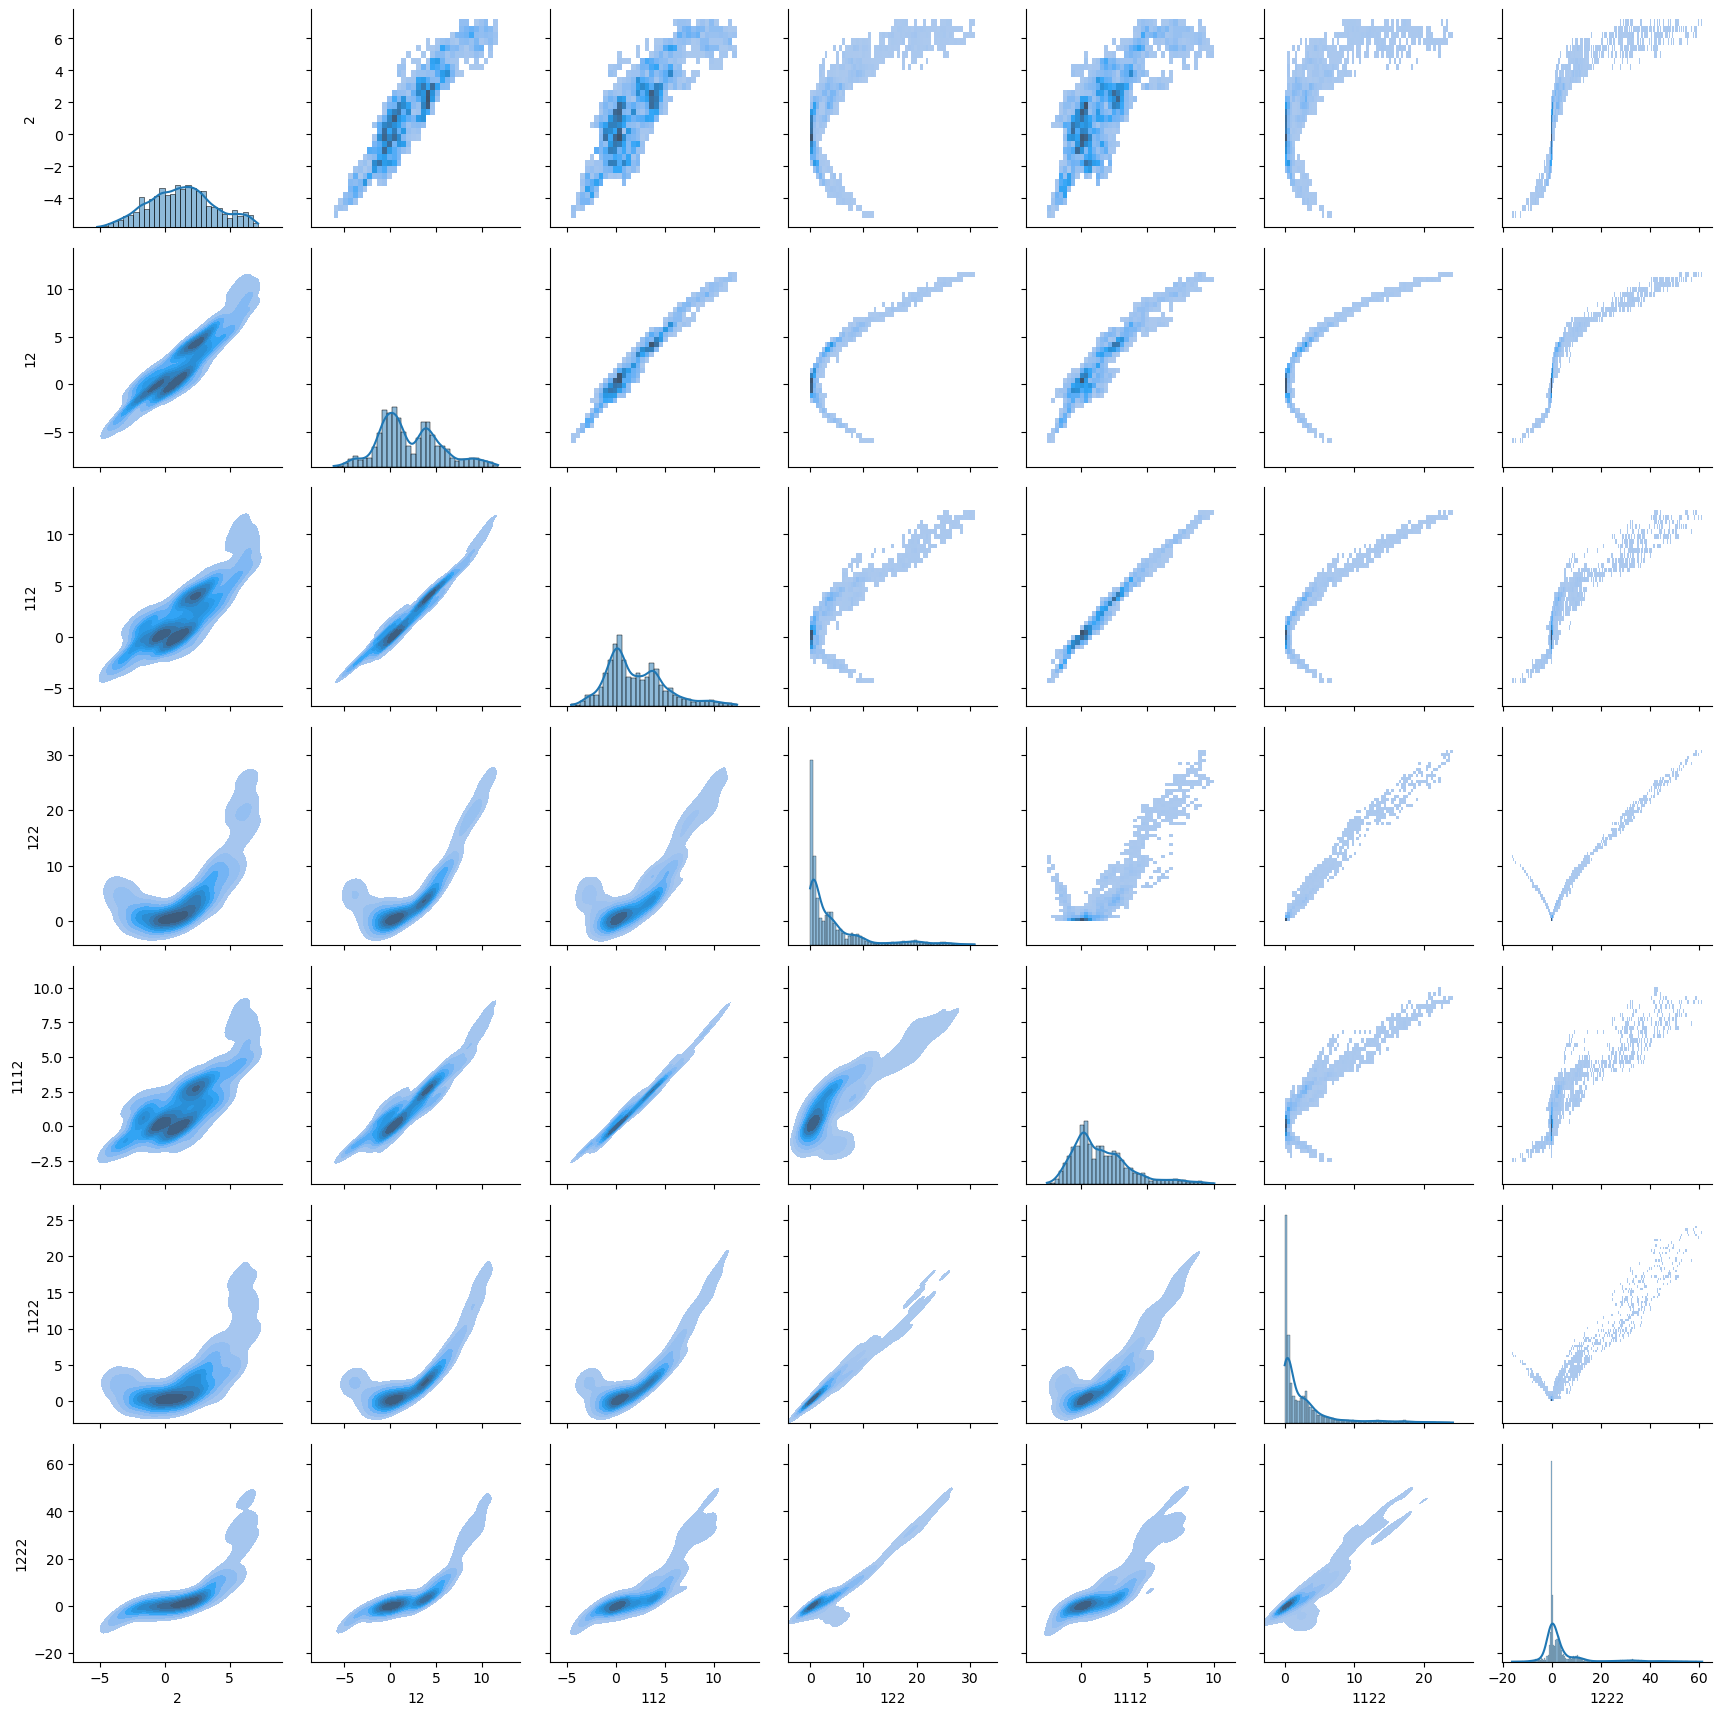

In [92]:
g2 = sns.PairGrid(DI1_cores_df[['2', '12', '112', '122', '1112', '1122', '1222']].loc['2005':]);
g2.map_upper(sns.histplot);
g2.map_lower(sns.kdeplot, fill=True);
g2.map_diag(sns.histplot, kde=True);

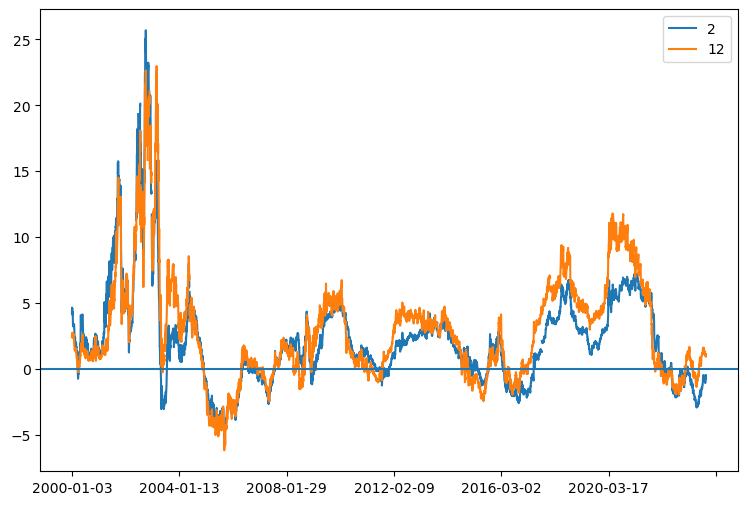

In [93]:
DI1_cores_df[['2', '12']].plot(figsize=(9, 6));
plt.axhline();

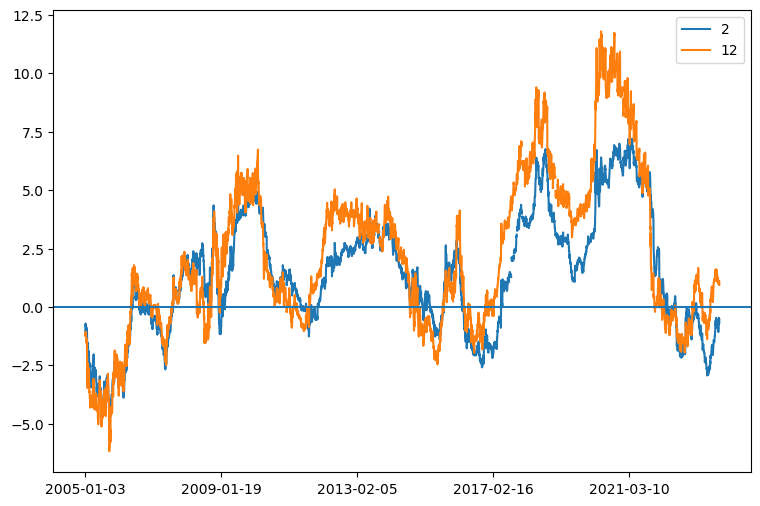

In [94]:
DI1_cores_df[['2', '12']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

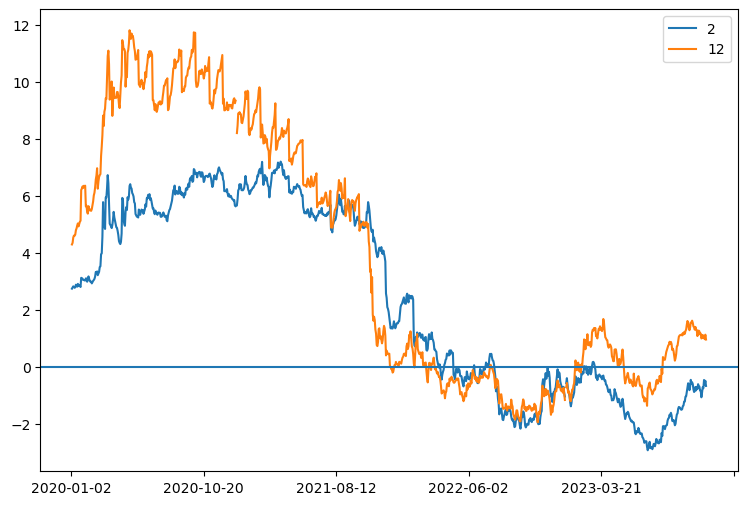

In [95]:
DI1_cores_df[['2', '12']].loc['2020':].plot(figsize=(9, 6));
plt.axhline();

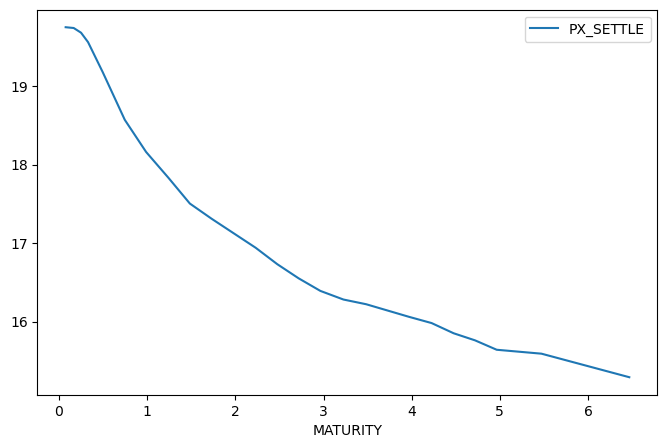

In [96]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2005-07-05'].set_index('MATURITY').plot();

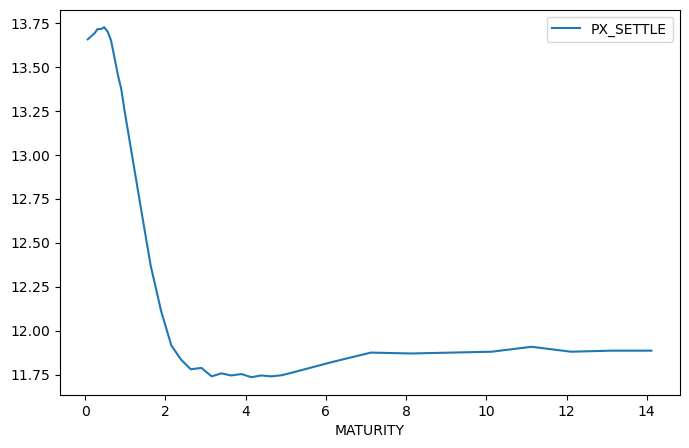

In [97]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2022-11-07'].set_index('MATURITY').plot();

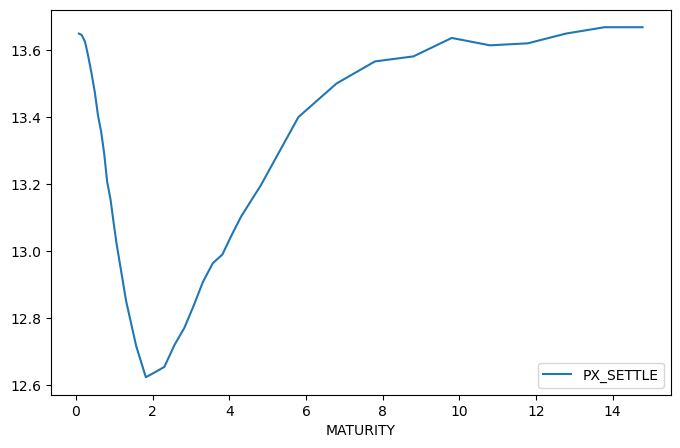

In [98]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2023-03-07'].set_index('MATURITY').plot();

In [99]:
DI1_cores_df.loc['2005-07-05']

1        2.268691
2       -4.460000
12      -4.695773
112     -3.181481
122      7.280912
1112    -1.676297
1122     3.463950
1222    -8.752364
11112   -0.726805
11122    1.344124
11212    1.680391
11222   -3.279508
12122   -3.387841
12222    8.470117
Name: 2005-07-05, dtype: float64

In [100]:
DI1_cores_df.loc['2022-11-07']

1        3.497273
2       -1.770000
12      -1.471110
112     -0.512814
122      1.273604
1112    -0.027693
1122     0.526203
1222    -0.708607
11112    0.072917
11122    0.154827
11212   -0.008596
11222   -0.265863
12122   -0.117899
12222    0.305126
Name: 2022-11-07, dtype: float64

In [101]:
DI1_cores_df.loc['2023-03-07']

1        3.569603
2        0.019000
12       1.309489
112      1.772586
122      0.460754
1112     1.401542
1122     0.580272
1222     0.126796
11112    0.839151
11122    0.397387
11212    0.101520
11222    0.155432
12122   -0.187863
12222    0.027921
Name: 2023-03-07, dtype: float64

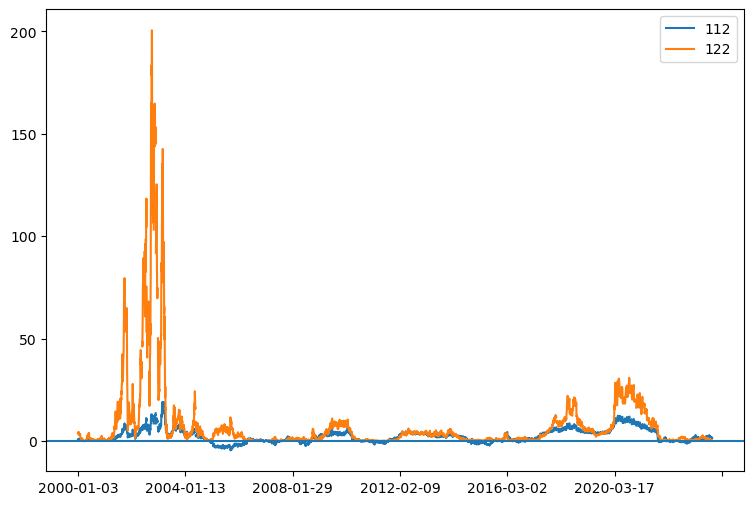

In [102]:
DI1_cores_df[['112', '122']].plot(figsize=(9, 6));
plt.axhline();

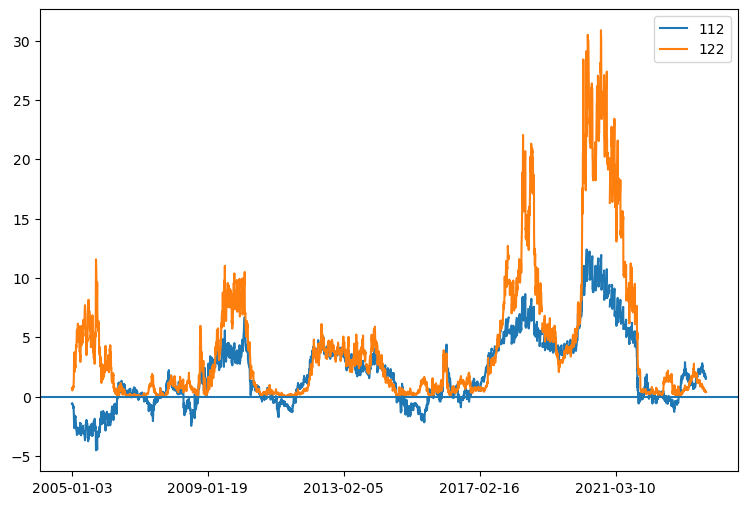

In [103]:
DI1_cores_df[['112', '122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

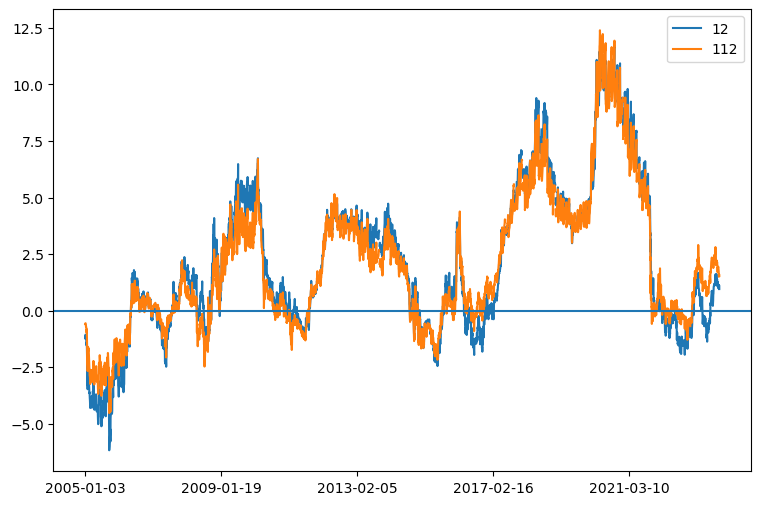

In [104]:
DI1_cores_df[['12', '112']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

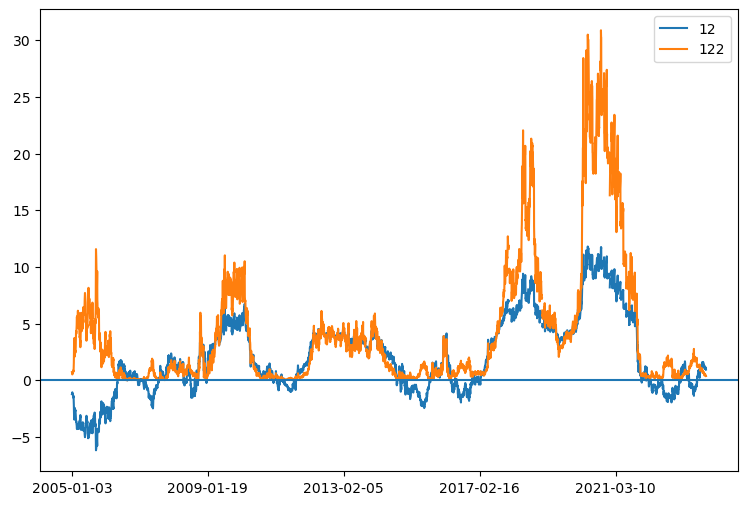

In [105]:
DI1_cores_df[['12', '122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

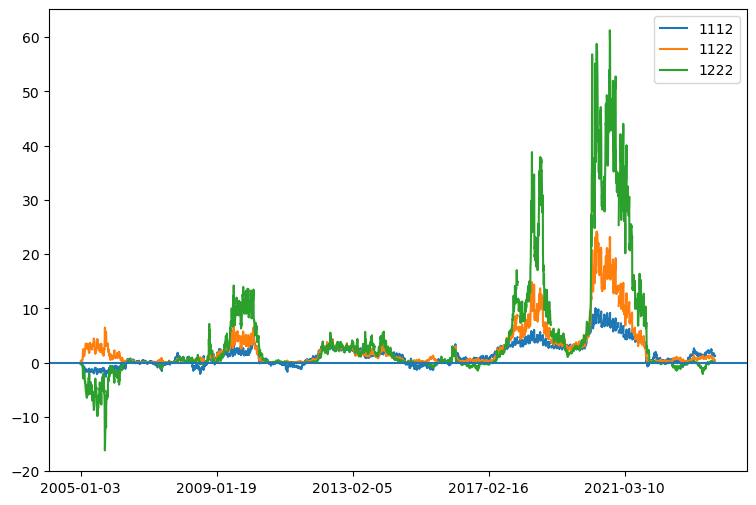

In [106]:
DI1_cores_df[['1112', '1122', '1222']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

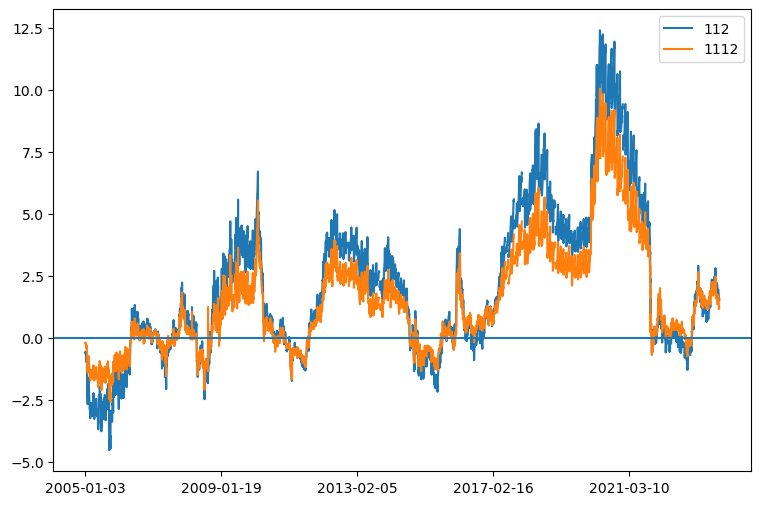

In [107]:
DI1_cores_df[['112', '1112']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

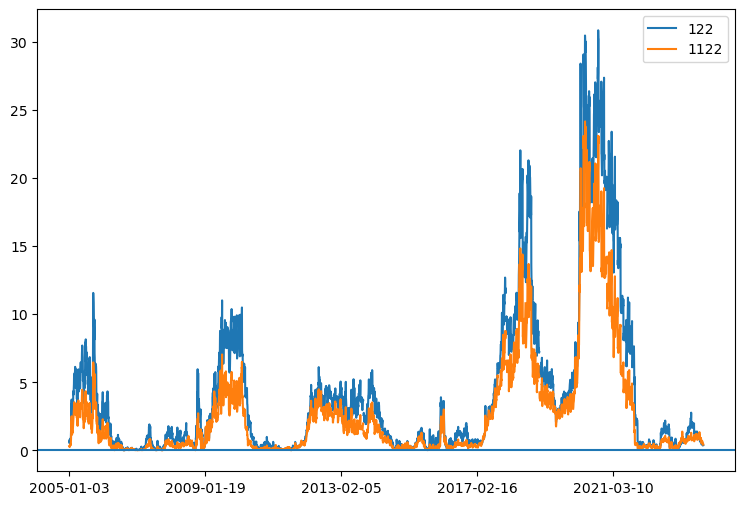

In [108]:
DI1_cores_df[['122', '1122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

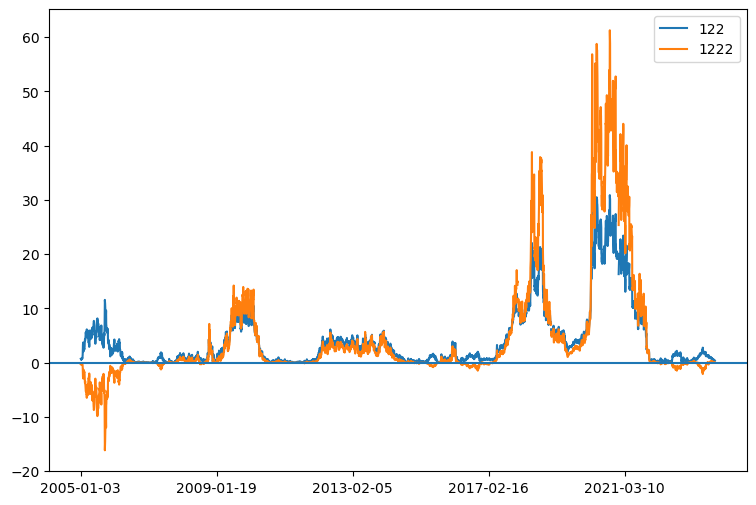

In [109]:
DI1_cores_df[['122', '1222']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

## Inversion

### Functions

### Defaults

#### Weights

In [421]:
weights_df = [50, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]

In [453]:
weights_L4_df = [50, 10, 10, 10, 10, 10, 10, 10, 0, 0, 0, 0, 0, 0]

#### Initial Guesses

In [340]:
x0_df_3 = [1., 0., 1., 0., 1., 0.]

In [341]:
x0_df_4 = [1., 0., 1., 0., 1., 0., 1., 0.]

#### Minimum interval between points

In [344]:
dt_min_df = min(0.05, np.sqrt(1 / 12))
dt_min_df

0.2

### 3 Segments - Old

In [358]:
def minimize3_old(core4sig, weights=weights_df[:8], x0=x0_df_3):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] -
                 core4sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] -
                 core4sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[2] * x[4] * x[5] -
                 core4sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[5] -
                 core4sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5] -
                 core4sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 -
                 core4sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 -
                 core4sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 -
                 core4sig[7]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x))
    cons = (
        {'type': 'ineq', 'fun': lambda x: x[0]},
        {'type': 'ineq', 'fun': lambda x: x[2]},
        {'type': 'ineq', 'fun': lambda x: x[4]})
    res = sc.optimize.minimize(fun, x0, method='SLSQP', 
                               constraints=cons, 
                               options={'ftol': 1e-8, 'maxiter': 1000})
    return res

### 3 Segments - New

In [359]:
def minimize3(core4sig, weights=weights_df[:8], x0=x0_df_3, dt_min=dt_min_df):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] -
                 core4sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] -
                 core4sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[2] * x[4] * x[5] -
                 core4sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[5] -
                 core4sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5] -
                 core4sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 -
                 core4sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 -
                 core4sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 -
                 core4sig[7]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) * 0 +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x))
    cons = (
        {'type': 'ineq', 'fun': lambda x: x[0] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[2] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[4] - dt_min},
        {'type': 'eq', 'fun' : lambda x: x[0] + x[2] + x[4] - core4sig[0]},
        # {'type': 'eq', 'fun' : lambda x: x[0] * x[1] + x[2] * x[3] + x[4] * x[5] - core4sig[1]},
        # {'type': 'eq', 'fun' : lambda x: (
        #     x[0] * x[0] * x[1] / 2 +
        #     x[2] * x[2] * x[3] / 2 +
        #     x[4] * x[4] * x[5] / 2 +
        #     x[0] * x[2] * x[3] +
        #     x[0] * x[4] * x[5] +
        #     x[2] * x[4] * x[5] -
        #     core4sig[2])}
    )
    res = sc.optimize.minimize(fun, x0, method='SLSQP', 
                               constraints=cons, 
                               options={'ftol': 1e-8, 'maxiter': 1000})
    return res

### 4 Segments - Level 4

In [360]:
def minimize4(core5sig, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] +
                 x[6] -
                 core5sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] +
                 x[6] * x[7] -
                 core5sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[0] * x[6] * x[7] +
                 x[2] * x[4] * x[5] +
                 x[2] * x[6] * x[7] +
                 x[4] * x[6] * x[7] -
                 core5sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[5]  +
                 x[0] * x[2] * x[6] * x[7]  +
                 x[0] * x[4] * x[6] * x[7]  +
                 x[2] * x[4] * x[6] * x[7] -
                 core5sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[1] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5]  +
                 x[0] * x[2] * x[6] * x[3] * x[7]  +
                 x[0] * x[4] * x[6] * x[5] * x[7]  +
                 x[2] * x[4] * x[6] * x[5] * x[7] -
                 core5sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[7]-
                 core5sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[7]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) * 0 +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x))
                # weights[8] * eq11112(x) +
                # weights[9] * eq11122(x) +
                # weights[10] * eq11212(x) +
                # weights[11] * eq11222(x) +
                # weights[12] * eq12122(x) +
                # weights[13] * eq12222(x))
    cons = (
        {'type': 'ineq', 'fun': lambda x: x[0] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[2] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[4] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[6] - dt_min},
        {'type': 'eq', 'fun' : lambda x: (x[0] + x[2] + x[4] + x[6] -
                                          core5sig[0])},
        # {'type': 'eq', 'fun' : lambda x: (x[0] * x[1] + x[2] * x[3] +
        #                                   x[4] * x[5] + x[6] * x[7] -
        #                                   core5sig[1])},
        # {'type': 'eq', 'fun' : lambda x: (
        #     x[0] * x[0] * x[1] / 2 +
        #     x[2] * x[2] * x[3] / 2 +
        #     x[4] * x[4] * x[5] / 2 +
        #     x[6] * x[6] * x[7] / 2 +
        #     x[0] * x[2] * x[3] +
        #     x[0] * x[4] * x[5] +
        #     x[0] * x[6] * x[7] +
        #     x[2] * x[4] * x[5] +
        #     x[2] * x[6] * x[7] +
        #     x[4] * x[6] * x[7] -
        #     core5sig[2])}
    )
    res = sc.optimize.minimize(fun, x0, method='SLSQP', 
                               constraints=cons, 
                               options={'ftol': 1e-8, 'maxiter': 1000})
    return res

### 4 Segments - Level 5

In [507]:
def minimize4L5(core5sig, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] +
                 x[6] -
                 core5sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] +
                 x[6] * x[7] -
                 core5sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[0] * x[6] * x[7] +
                 x[2] * x[4] * x[5] +
                 x[2] * x[6] * x[7] +
                 x[4] * x[6] * x[7] -
                 core5sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[5]  +
                 x[0] * x[2] * x[6] * x[7]  +
                 x[0] * x[4] * x[6] * x[7]  +
                 x[2] * x[4] * x[6] * x[7] -
                 core5sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[1] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5]  +
                 x[0] * x[2] * x[6] * x[3] * x[7]  +
                 x[0] * x[4] * x[6] * x[5] * x[7]  +
                 x[2] * x[4] * x[6] * x[5] * x[7] -
                 core5sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[7]-
                 core5sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[7]) ** 2)
    def eq11112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 2 -
                 core5sig[8]) ** 2)
    def eq11122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 2 -
                 core5sig[9]) ** 2)
    def eq11212(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] / 2 -
                 core5sig[10]) ** 2)
    def eq11222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 -
                 core5sig[11]) ** 2)
    def eq12122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 -
                 core5sig[12]) ** 2)
    def eq12222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 2 -
                 core5sig[13]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) * 0 +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x) +
                weights[8] * eq11112(x) +
                weights[9] * eq11122(x) +
                weights[10] * eq11212(x) +
                weights[11] * eq11222(x) +
                weights[12] * eq12122(x) +
                weights[13] * eq12222(x))
    bounds = [(dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.)]
    cons = (
        {'type': 'ineq', 'fun': lambda x: x[0] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[2] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[4] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[6] - dt_min},
        {'type': 'eq', 'fun' : lambda x: (x[0] + x[2] + x[4] + x[6] -
                                          core5sig[0])},
        # {'type': 'eq', 'fun' : lambda x: (x[0] * x[1] + x[2] * x[3] +
        #                                   x[4] * x[5] + x[6] * x[7] -
        #                                   core5sig[1])},
        # {'type': 'eq', 'fun' : lambda x: (
        #     x[0] * x[0] * x[1] / 2 +
        #     x[2] * x[2] * x[3] / 2 +
        #     x[4] * x[4] * x[5] / 2 +
        #     x[6] * x[6] * x[7] / 2 +
        #     x[0] * x[2] * x[3] +
        #     x[0] * x[4] * x[5] +
        #     x[0] * x[6] * x[7] +
        #     x[2] * x[4] * x[5] +
        #     x[2] * x[6] * x[7] +
        #     x[4] * x[6] * x[7] -
        #     core5sig[2])}
    )
    res = sc.optimize.minimize(fun, x0, method='SLSQP', bounds=bounds,
                               constraints=cons, 
                               options={'ftol': 1e-8, 'maxiter': 1000})
    return res

### 4 Segments - Level 5 - TC

In [503]:
def minimize4L5_TC(core5sig, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] +
                 x[6] -
                 core5sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] +
                 x[6] * x[7] -
                 core5sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[0] * x[6] * x[7] +
                 x[2] * x[4] * x[5] +
                 x[2] * x[6] * x[7] +
                 x[4] * x[6] * x[7] -
                 core5sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[5]  +
                 x[0] * x[2] * x[6] * x[7]  +
                 x[0] * x[4] * x[6] * x[7]  +
                 x[2] * x[4] * x[6] * x[7] -
                 core5sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[1] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5]  +
                 x[0] * x[2] * x[6] * x[3] * x[7]  +
                 x[0] * x[4] * x[6] * x[5] * x[7]  +
                 x[2] * x[4] * x[6] * x[5] * x[7] -
                 core5sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[7]-
                 core5sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[7]) ** 2)
    def eq11112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 2 -
                 core5sig[8]) ** 2)
    def eq11122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 2 -
                 core5sig[9]) ** 2)
    def eq11212(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] / 2 -
                 core5sig[10]) ** 2)
    def eq11222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 -
                 core5sig[11]) ** 2)
    def eq12122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 -
                 core5sig[12]) ** 2)
    def eq12222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 2 -
                 core5sig[13]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) * 0 +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x) +
                weights[8] * eq11112(x) +
                weights[9] * eq11122(x) +
                weights[10] * eq11212(x) +
                weights[11] * eq11222(x) +
                weights[12] * eq12122(x) +
                weights[13] * eq12222(x))
    bounds = [(dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.)]
    cons = (
        {'type': 'ineq', 'fun': lambda x: x[0] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[2] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[4] - dt_min},
        {'type': 'ineq', 'fun': lambda x: x[6] - dt_min},
        {'type': 'eq', 'fun' : lambda x: (x[0] + x[2] + x[4] + x[6] -
                                          core5sig[0])},
        # {'type': 'eq', 'fun' : lambda x: (x[0] * x[1] + x[2] * x[3] +
        #                                   x[4] * x[5] + x[6] * x[7] -
        #                                   core5sig[1])},
        # {'type': 'eq', 'fun' : lambda x: (
        #     x[0] * x[0] * x[1] / 2 +
        #     x[2] * x[2] * x[3] / 2 +
        #     x[4] * x[4] * x[5] / 2 +
        #     x[6] * x[6] * x[7] / 2 +
        #     x[0] * x[2] * x[3] +
        #     x[0] * x[4] * x[5] +
        #     x[0] * x[6] * x[7] +
        #     x[2] * x[4] * x[5] +
        #     x[2] * x[6] * x[7] +
        #     x[4] * x[6] * x[7] -
        #     core5sig[2])}
    )
    res = sc.optimize.minimize(fun, x0, method='trust-constr', 
                               bounds=bounds, constraints=cons)
    return res

### 4 Segments - Level 5 - Global

In [486]:
def minimize_G_4L5(core5sig, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    def eq1(x):
        return ((x[0] +
                 x[2] +
                 x[4] +
                 x[6] -
                 core5sig[0]) ** 2)
    def eq2(x):
        return ((x[0] * x[1] +
                 x[2] * x[3] +
                 x[4] * x[5] +
                 x[6] * x[7] -
                 core5sig[1]) ** 2)
    def eq12(x):
        return ((x[0] * x[0] * x[1] / 2 +
                 x[2] * x[2] * x[3] / 2 +
                 x[4] * x[4] * x[5] / 2 +
                 x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[3] +
                 x[0] * x[4] * x[5] +
                 x[0] * x[6] * x[7] +
                 x[2] * x[4] * x[5] +
                 x[2] * x[6] * x[7] +
                 x[4] * x[6] * x[7] -
                 core5sig[2]) ** 2)
    def eq112(x):
        return ((x[0] * x[0] * x[0] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[5]  +
                 x[0] * x[2] * x[6] * x[7]  +
                 x[0] * x[4] * x[6] * x[7]  +
                 x[2] * x[4] * x[6] * x[7] -
                 core5sig[3]) ** 2)
    def eq122(x):
        return ((x[0] * x[0] * x[0] * x[1] * x[1] / 6 +
                 x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[1] * x[3] / 2 +
                 x[0] * x[0] * x[4] * x[1] * x[5] / 2 +
                 x[0] * x[0] * x[6] * x[1] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[3] * x[3] / 2 +
                 x[0] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[3] * x[5]  +
                 x[0] * x[2] * x[6] * x[3] * x[7]  +
                 x[0] * x[4] * x[6] * x[5] * x[7]  +
                 x[2] * x[4] * x[6] * x[5] * x[7] -
                 core5sig[4]) ** 2)
    def eq1112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[7]-
                 core5sig[5]) ** 2)
    def eq1122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[6]) ** 2)
    def eq1222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 2 +
                 x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 2 +
                 x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 2 +
                 x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[4] * x[4] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[6] * x[5] * x[7]-
                 core5sig[7]) ** 2)
    def eq11112(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] / 2 -
                 core5sig[8]) ** 2)
    def eq11122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 2 -
                 core5sig[9]) ** 2)
    def eq11212(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] / 2 -
                 core5sig[10]) ** 2)
    def eq11222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 2 -
                 core5sig[11]) ** 2)
    def eq12122(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] / 2 -
                 core5sig[12]) ** 2)
    def eq12222(x):
        return ((x[0] * x[0] * x[0] * x[0] * x[0] * x[1] * x[1] * x[1] * x[1] / 120 +
                 x[2] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 120 +
                 x[4] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 120 +
                 x[6] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 120 +
                 x[0] * x[0] * x[0] * x[0] * x[2] * x[1] * x[1] * x[1] * x[3] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[4] * x[1] * x[1] * x[1] * x[5] / 24 +
                 x[0] * x[0] * x[0] * x[0] * x[6] * x[1] * x[1] * x[1] * x[7] / 24 +
                 x[0] * x[2] * x[2] * x[2] * x[2] * x[3] * x[3] * x[3] * x[3] / 24 +
                 x[0] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[0] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 24 +
                 x[2] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 24 +
                 x[2] * x[4] * x[4] * x[4] * x[4] * x[5] * x[5] * x[5] * x[5] / 24 +
                 x[2] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[4] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 24 +
                 x[4] * x[6] * x[6] * x[6] * x[6] * x[7] * x[7] * x[7] * x[7] / 24 +
                 x[0] * x[0] * x[0] * x[2] * x[2] * x[1] * x[1] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[0] * x[4] * x[4] * x[1] * x[1] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[0] * x[6] * x[6] * x[1] * x[1] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[2] * x[2] * x[2] * x[1] * x[3] * x[3] * x[3] / 12 +
                 x[0] * x[0] * x[4] * x[4] * x[4] * x[1] * x[5] * x[5] * x[5] / 12 +
                 x[0] * x[0] * x[6] * x[6] * x[6] * x[1] * x[7] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 12 +
                 x[2] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 12 +
                 x[2] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 12 +
                 x[4] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 12 +
                 x[0] * x[0] * x[0] * x[2] * x[4] * x[1] * x[1] * x[3] * x[5] / 6 +
                 x[0] * x[0] * x[0] * x[2] * x[6] * x[1] * x[1] * x[3] * x[7] / 6 +
                 x[0] * x[0] * x[0] * x[4] * x[6] * x[1] * x[1] * x[5] * x[7] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[4] * x[3] * x[3] * x[3] * x[5] / 6 +
                 x[0] * x[2] * x[2] * x[2] * x[6] * x[3] * x[3] * x[3] * x[7] / 6 +
                 x[0] * x[2] * x[4] * x[4] * x[4] * x[3] * x[5] * x[5] * x[5] / 6 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[0] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[2] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[4] * x[4] * x[6] * x[5] * x[5] * x[5] * x[7] / 6 +
                 x[2] * x[4] * x[6] * x[6] * x[6] * x[5] * x[7] * x[7] * x[7] / 6 +
                 x[0] * x[0] * x[2] * x[2] * x[4] * x[1] * x[3] * x[3] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[2] * x[6] * x[1] * x[3] * x[3] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[4] * x[1] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[0] * x[2] * x[6] * x[6] * x[1] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[4] * x[6] * x[1] * x[5] * x[5] * x[7] / 4 +
                 x[0] * x[0] * x[4] * x[6] * x[6] * x[1] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[2] * x[2] * x[4] * x[4] * x[3] * x[3] * x[5] * x[5] / 4 +
                 x[0] * x[2] * x[2] * x[6] * x[6] * x[3] * x[3] * x[7] * x[7] / 4 +
                 x[0] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 4 +
                 x[2] * x[2] * x[4] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 4 +
                 x[2] * x[4] * x[4] * x[6] * x[6] * x[5] * x[5] * x[7] * x[7] / 4 +
                 x[0] * x[0] * x[2] * x[4] * x[6] * x[1] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[2] * x[4] * x[6] * x[3] * x[3] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[4] * x[4] * x[6] * x[3] * x[5] * x[5] * x[7] / 2 +
                 x[0] * x[2] * x[6] * x[6] * x[6] * x[3] * x[5] * x[7] * x[7] / 2 -
                 core5sig[13]) ** 2)
    def fun(x):
        return (weights[0] * eq1(x) +
                weights[1] * eq2(x) +
                weights[2] * eq12(x) +
                weights[3] * eq112(x) +
                weights[4] * eq122(x) +
                weights[5] * eq1112(x) +
                weights[6] * eq1122(x) +
                weights[7] * eq1222(x) +
                weights[8] * eq11112(x) +
                weights[9] * eq11122(x) +
                weights[10] * eq11212(x) +
                weights[11] * eq11222(x) +
                weights[12] * eq12122(x) +
                weights[13] * eq12222(x))
    bounds = [(dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.),
              (dt_min, core5sig[0]),
              (-100., +100.)]
    # lc = sc.optimize.LinearConstraint(
    #     [[1, 0, 1, 0, 1, 0, 1, 0]],
    #     core5sig[0] - 0.0001, core5sig[0] + 0.0001)
    # con = lambda x: (x[0] + x[2] + x[4] + x[6] - core5sig[0])
    # cons = (
        # {'type': 'ineq', 'fun': lambda x: x[0] - dt_min},
        # {'type': 'ineq', 'fun': lambda x: x[2] - dt_min},
        # {'type': 'ineq', 'fun': lambda x: x[4] - dt_min},
        # {'type': 'ineq', 'fun': lambda x: x[6] - dt_min},
        # {'type': 'eq', 'fun' : lambda x: (x[0] + x[2] + x[4] + x[6] -
        #                                   core5sig[0])},
        # {'type': 'eq', 'fun' : lambda x: (x[0] * x[1] + x[2] * x[3] +
        #                                   x[4] * x[5] + x[6] * x[7] -
        #                                   core5sig[1])},
        # {'type': 'eq', 'fun' : lambda x: (
        #     x[0] * x[0] * x[1] / 2 +
        #     x[2] * x[2] * x[3] / 2 +
        #     x[4] * x[4] * x[5] / 2 +
        #     x[6] * x[6] * x[7] / 2 +
        #     x[0] * x[2] * x[3] +
        #     x[0] * x[4] * x[5] +
        #     x[0] * x[6] * x[7] +
        #     x[2] * x[4] * x[5] +
        #     x[2] * x[6] * x[7] +
        #     x[4] * x[6] * x[7] -
        #     core5sig[2])}
    # )
    # res = sc.optimize.shgo(fun, bounds=bounds, constraints=cons)
    # res = sc.optimize.differential_evolution(fun, bounds=bounds, constraints=lc)
    res = sc.optimize.dual_annealing(fun, bounds=bounds, x0=x0)
    return res

### Results

In [378]:
def x_to_tb(x):
    n = len(x) // 2
    return [[x[2*j] for j in range (n)], [x[2*j +1] for j in range (n)]]

In [379]:
def rec_from_tb(x, t0, r0, seg=3, lev=4):
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=' + str(seg) + ' L=' + str(lev)])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [422]:
minimize3(DI1_cores_df.loc['2022-11-07'].values[:8])

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0005234964558713848
       x: [ 6.490e-01  1.499e-02  4.901e-01 -3.802e+00  2.358e+00
            3.536e-02]
     nit: 104
     jac: [ 8.198e-04  7.276e-05  2.968e-04  1.012e-04  1.285e-03
            1.477e-03]
    nfev: 762
    njev: 104

In [423]:
minimize4(DI1_cores_df.loc['2022-11-07'].values[:8])

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.00017228512114109736
       x: [ 4.155e-01  3.900e-01  1.008e+00 -2.188e+00  9.621e-01
            2.809e-01  1.112e+00  1.891e-03]
     nit: 32
     jac: [-5.895e-04  1.252e-04 -8.744e-04  4.086e-04 -2.224e-04
            7.827e-04 -2.443e-05  1.585e-03]
    nfev: 302
    njev: 32

In [508]:
%%time

minimize4L5(DI1_cores_df.loc['2022-11-07'].values)

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


CPU times: user 259 ms, sys: 6.08 ms, total: 265 ms
Wall time: 261 ms


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 4.9210731322636494e-05
       x: [ 5.432e-01  1.298e-01  7.350e-01 -2.728e+00  1.610e+00
            1.059e-01  6.092e-01 -9.138e-03]
     nit: 95
     jac: [-6.943e-04  1.023e-04 -1.595e-03  3.390e-04  1.067e-04
            1.685e-03 -8.896e-05  1.293e-03]
    nfev: 880
    njev: 95

In [509]:
%%time

minimize4L5_TC(DI1_cores_df.loc['2022-11-07'].values)

CPU times: user 2.67 s, sys: 1.81 s, total: 4.48 s
Wall time: 3.46 s


           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 4.921461644788743e-05
                 x: [ 5.431e-01  1.300e-01  7.351e-01 -2.728e+00  1.608e+00
                      1.060e-01  6.115e-01 -8.940e-03]
               nit: 592
              nfev: 5823
              njev: 647
              nhev: 0
          cg_niter: 2408
      cg_stop_cond: 4
              grad: [-6.403e-05  1.082e-06 -5.846e-05 -7.641e-08 -6.936e-05
                     -2.053e-06 -6.422e-05 -3.982e-06]
   lagrangian_grad: [ 1.320e-07  1.082e-06  9.808e-07 -7.639e-08 -1.283e-06
                     -2.053e-06  1.699e-07 -3.981e-06]
            constr: [array([ 3.431e-01]), array([ 5.351e-01]), array([ 1.408e+00]), array([ 4.115e-01]), array([ 0.000e+00]), array([ 5.431e-01,  1.300e-01,  7.351e-01, -2.728e+00,
                            1.608e+00,  1.060e-01,  6.115e-01, -8.940e-03])]
               jac: [array([[ 1.000e+00,  0.000e+00,  0

In [487]:
%%time

minimize_G_4L5(DI1_cores_df.loc['2022-11-07'].values)

CPU times: user 4.2 s, sys: 81.6 ms, total: 4.29 s
Wall time: 4.22 s


 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 0.0011945502636339154
       x: [ 5.236e-01  1.851e-01  7.773e-01 -2.684e+00  8.649e-01
            2.264e-01  1.332e+00  1.870e-02]
     nit: 1000
    nfev: 17036
    njev: 115
    nhev: 0

### Results - DI1

In [354]:
def DI1_from_sign_S3L4(date, weights=weights_df[:8], x0=x0_df_3, dt_min=dt_min_df):
    base_cores = DI1_cores_df.loc[date]
    result = minimize3(base_cores.values[:8], weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=3 L=4'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [355]:
def DI1_from_sign_S4L4(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = DI1_cores_df.loc[date]
    result = minimize4(base_cores.values[:8], weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=4'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [356]:
def DI1_from_sign_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = DI1_cores_df.loc[date]
    result = minimize4L5(base_cores.values, weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=5'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [494]:
def DI1_from_sign_S4L5_TC(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = DI1_cores_df.loc[date]
    result = minimize4L5_TC(base_cores.values, weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=5'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [394]:
def DI1_from_sign_G_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = DI1_cores_df.loc[date]
    result = minimize_G_4L5(base_cores.values, weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=5'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [529]:
def SOFR_from_sign_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = SOFR_cores_df.loc[date]
    result = minimize4L5(base_cores.values, weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = get_sofr_str_mats(sofr_dict_sqrt_mats_10, (df_SOFR.loc[date])['MATURITY'].values)
    rates = df_SOFR.loc[date]['PX_LAST'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=5'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [528]:
def SOFR_from_sign_S4L5_TC(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    base_cores = SOFR_cores_df.loc[date]
    result = minimize4L5_TC(base_cores.values, weights, x0, dt_min)
    x = result.x
    n = len(x) // 2
    p_arr = [[x[2*j], x[2*j +1]] for j in range (n)]
    mats = get_sofr_str_mats(sofr_dict_sqrt_mats_10, (df_SOFR.loc[date])['MATURITY'].values)
    rates = df_SOFR.loc[date]['PX_LAST'].values
    t0 = mats[0]
    r0 = rates[0]
    pts = [[t0, r0]]
    for p in p_arr:
        pts = pts +[[pts[-1][0] + p[0], pts[-1][1] + p[1] * p[0]]]
    df = pd.DataFrame(pts, columns=['Sqrt(t)', 'InvSig S=4 L=5'])
    df.set_index('Sqrt(t)', inplace=True)
    return df

In [426]:
DI1_from_sign_S3L4('2022-11-07')

,InvSig S=3 L=4
Sqrt(t),
0.259731,13.656000
0.908686,13.665726
1.398745,11.802421
3.757004,11.885819


In [427]:
DI1_from_sign_S4L4('2022-11-07')

,InvSig S=4 L=4
Sqrt(t),
0.259731,13.656000
0.675193,13.818051
1.682783,11.613765
2.644898,11.884006
3.757004,11.886109


In [428]:
DI1_from_sign_S4L5('2022-11-07')

,InvSig S=4 L=5
Sqrt(t),
0.259731,13.656000
0.800585,13.728109
1.540191,11.721602
3.167111,11.892343
3.757004,11.886006


In [429]:
DI1_from_sign_G_S4L5('2022-11-07')

,InvSig S=4 L=5
Sqrt(t),
0.259731,13.656000
0.800248,13.728426
1.540483,11.721284
3.159484,11.891989
3.757009,11.886003


In [430]:
SOFR_from_sign_S4L5('2022-11-07')

,InvSig S=4 L=5
Sqrt(t),
0.288675,3.799600
0.930521,4.999322
2.435123,4.079110
2.635123,3.987379
3.162278,3.943158


In [362]:
def plot_DI1_Inv_S3L4(date, weights=weights_df[:8], x0=x0_df_3, dt_min=dt_min_df):
    ax = sqrtt_DI1(date).plot(color='b', marker='x', label='Market', title='DI1 ' + date);
    DI1_from_sign_S3L4(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [363]:
def plot_DI1_Inv_S4L4(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_DI1(date).plot(color='b', marker='x', label='Market', title='DI1 ' + date);
    DI1_from_sign_S4L4(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [364]:
def plot_DI1_Inv_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_DI1(date).plot(color='b', marker='x', label='Market', title='DI1 ' + date);
    DI1_from_sign_S4L5(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [495]:
def plot_DI1_Inv_S4L5_TC(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_DI1(date).plot(color='b', marker='x', label='Market', title='DI1 ' + date);
    DI1_from_sign_S4L5_TC(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [396]:
def plot_DI1_Inv_G_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_DI1(date).plot(color='b', marker='x', label='Market', title='DI1 ' + date);
    DI1_from_sign_G_S4L5(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [365]:
def plot_SOFR_Inv_S4L5(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_SOFR(date).plot(color='b', marker='x', label='Market', title='SOFR ' + date);
    SOFR_from_sign_S4L5(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

In [530]:
def plot_SOFR_Inv_S4L5_TC(date, weights=weights_df, x0=x0_df_4, dt_min=dt_min_df):
    ax = sqrtt_SOFR(date).plot(color='b', marker='x', label='Market', title='SOFR ' + date);
    SOFR_from_sign_S4L5_TC(date, weights, x0, dt_min).plot(color='r', marker='o', ax=ax);
    plt.legend();

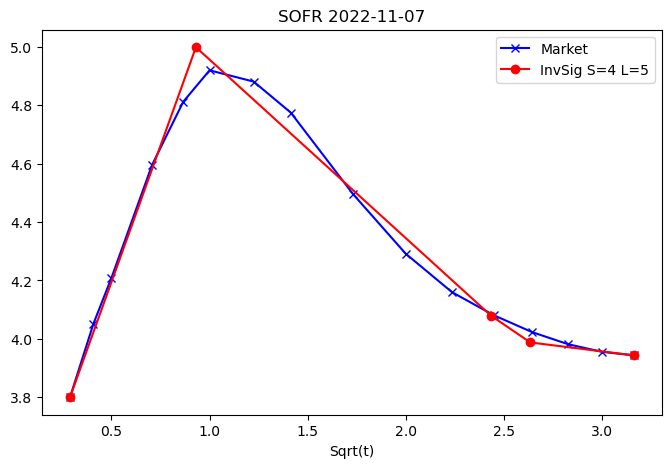

In [431]:
plot_SOFR_Inv_S4L5('2022-11-07')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


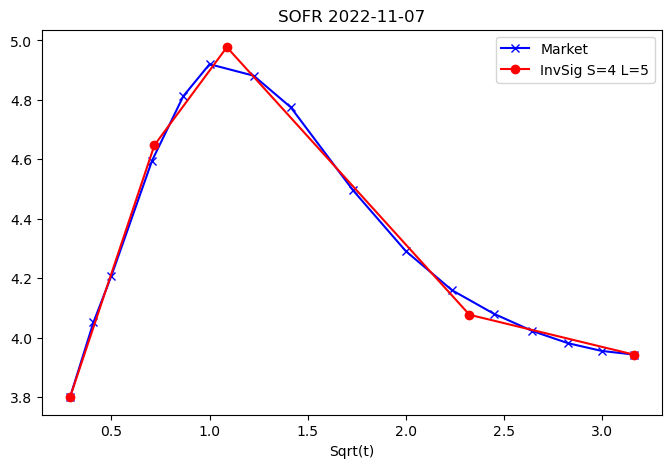

In [531]:
plot_SOFR_Inv_S4L5_TC('2022-11-07')

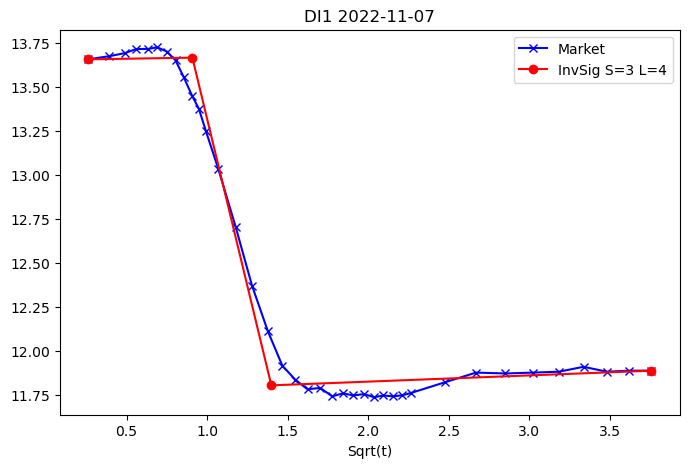

In [432]:
plot_DI1_Inv_S3L4('2022-11-07')

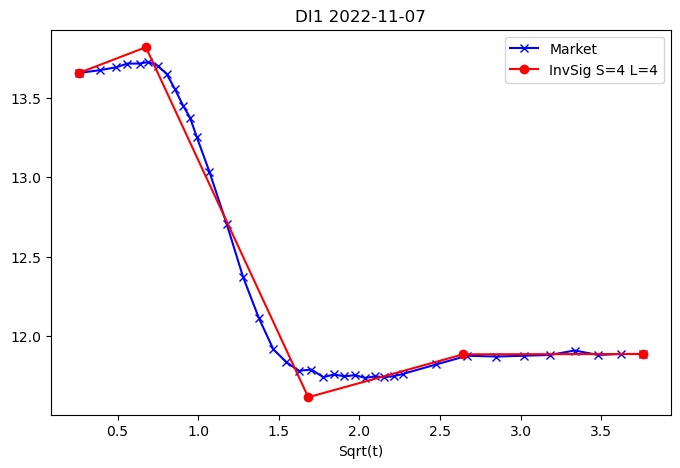

In [510]:
plot_DI1_Inv_S4L4('2022-11-07')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


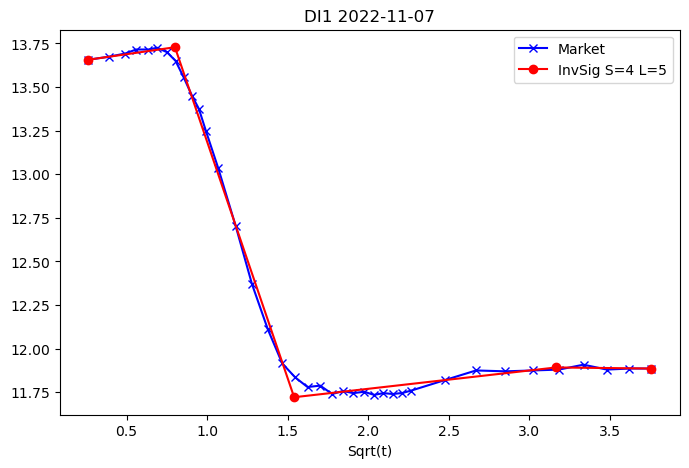

In [511]:
plot_DI1_Inv_S4L5('2022-11-07')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


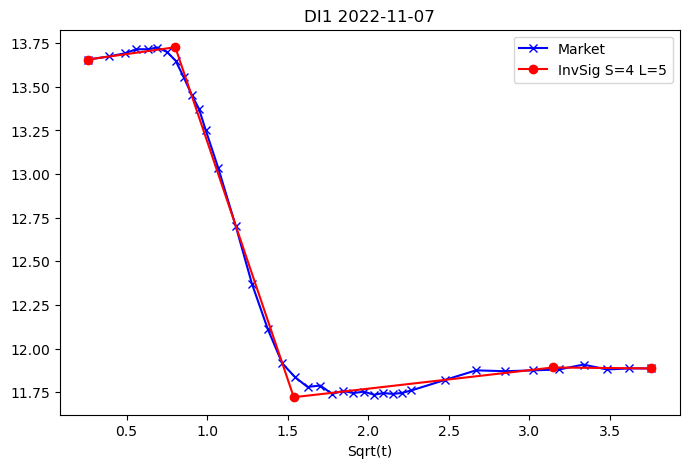

In [512]:
plot_DI1_Inv_S4L5_TC('2022-11-07')

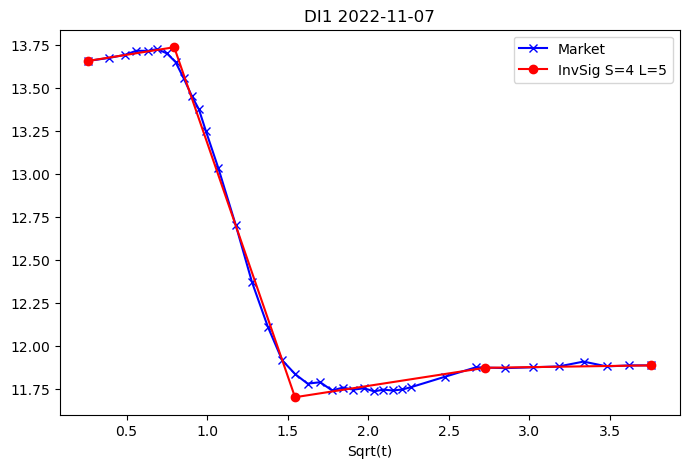

In [513]:
plot_DI1_Inv_G_S4L5('2022-11-07')

In [519]:
DI1_cores_df.loc['2022-11-07']

1        3.497273
2       -1.770000
12      -1.471110
112     -0.512814
122      1.273604
1112    -0.027693
1122     0.526203
1222    -0.708607
11112    0.072917
11122    0.154827
11212   -0.008596
11222   -0.265863
12122   -0.117899
12222    0.305126
Name: 2022-11-07, dtype: float64

In [520]:
DI1_cores_df.loc['2023-02-14']

1        3.661909
2        0.011000
12       0.935000
112      1.443067
122      0.249826
1112     1.248579
1122     0.355914
1222     0.052558
11112    0.799895
11122    0.269439
11212    0.006082
11222    0.072493
12122   -0.112944
12222    0.008882
Name: 2023-02-14, dtype: float64

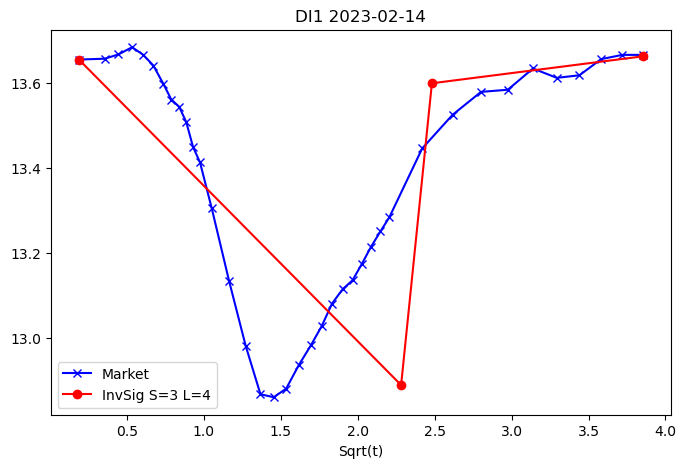

In [521]:
plot_DI1_Inv_S3L4('2023-02-14')

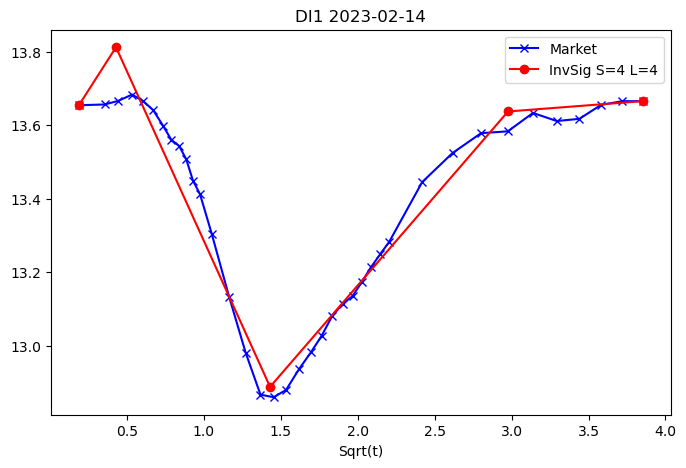

In [522]:
plot_DI1_Inv_S4L4('2023-02-14')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


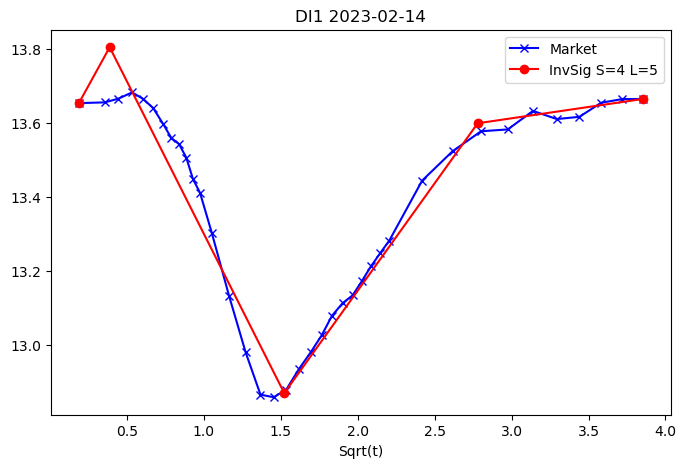

In [523]:
plot_DI1_Inv_S4L5('2023-02-14')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


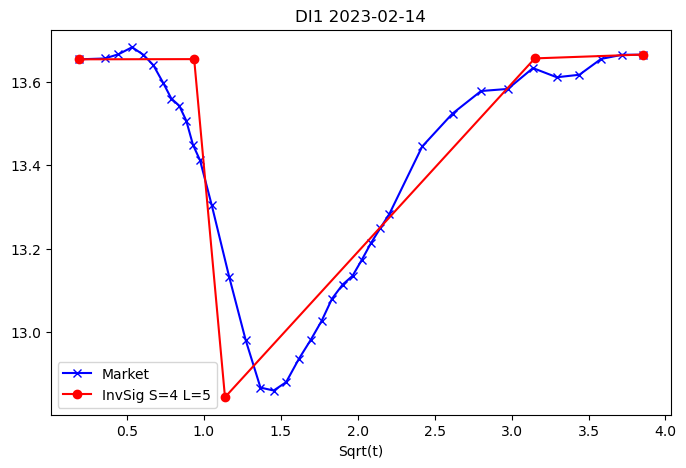

In [524]:
plot_DI1_Inv_S4L5_TC('2023-02-14')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


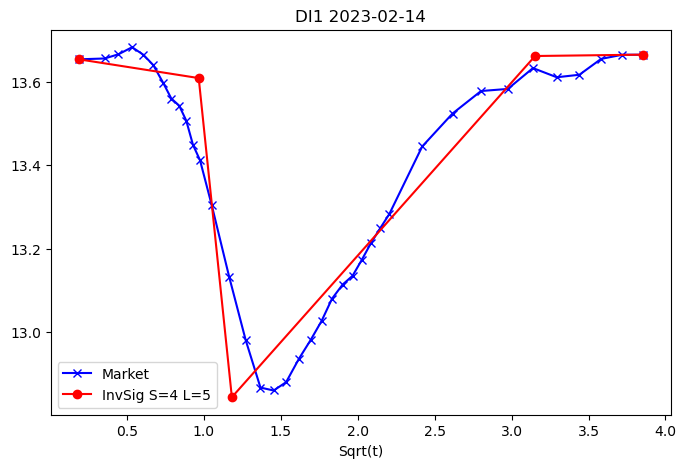

In [518]:
plot_DI1_Inv_S4L5_TC('2023-02-14', weights=weights_L4_df)

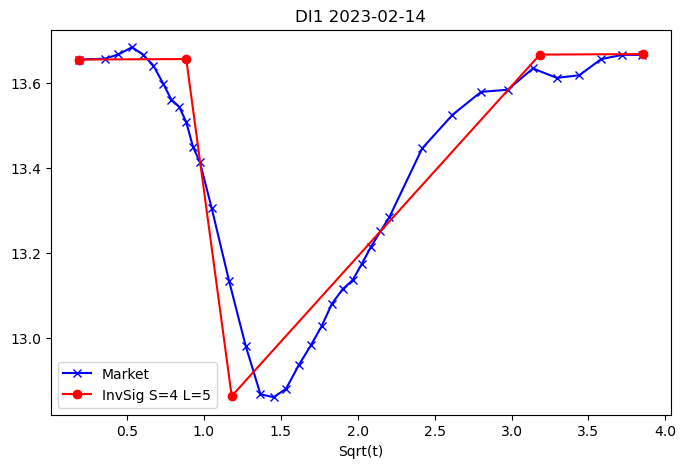

In [489]:
plot_DI1_Inv_G_S4L5('2023-02-14')

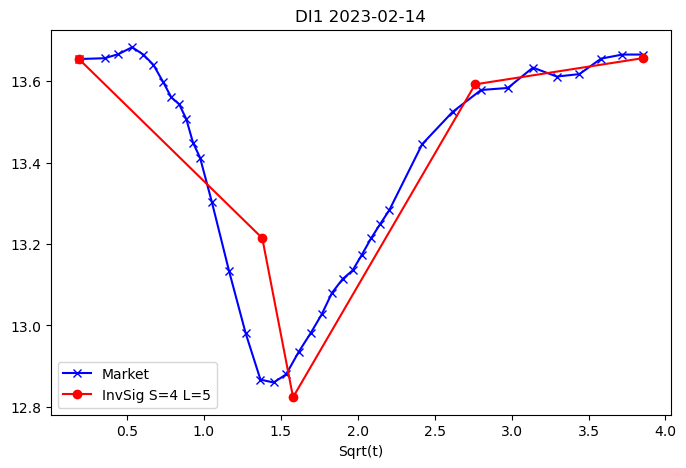

In [490]:
plot_DI1_Inv_G_S4L5('2023-02-14', weights=weights_df)

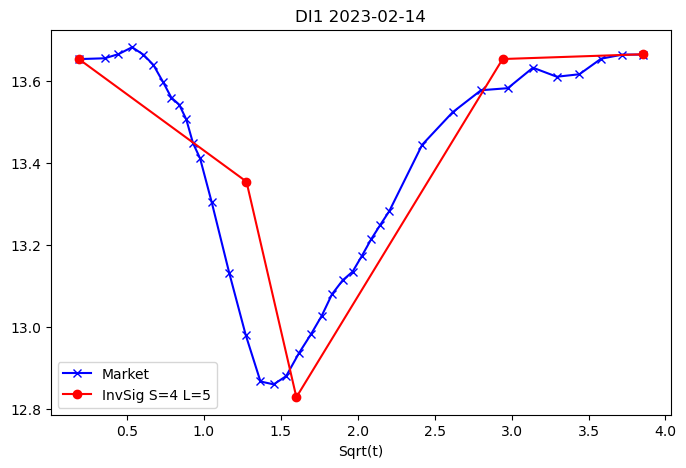

In [491]:
plot_DI1_Inv_G_S4L5('2023-02-14', weights=weights_L4_df)

In [382]:
minimize4L5(DI1_cores_df.loc['2023-02-14'].values)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0018618265001125276
       x: [ 2.404e-01  6.088e-01  1.048e+00 -8.806e-01  1.383e+00
            5.323e-01  9.900e-01  5.194e-02]
     nit: 66
     jac: [-3.852e-03 -5.871e-04 -3.498e-03 -1.407e-03 -4.852e-03
           -2.381e-03 -4.166e-03 -4.532e-03]
    nfev: 609
    njev: 66

In [380]:
x_to_tb(minimize4L5(DI1_cores_df.loc['2023-02-14'].values).x)

[[0.24038342856355663,
  1.0482654427802112,
  1.383283093255135,
  0.9899772644359994],
 [0.6087783040975843,
  -0.8805617703488609,
  0.5322881015423816,
  0.05194318220662016]]

In [385]:
minimize4L5(DI1_cores_df.loc['2023-02-14'].values, x0=[ 0.25, 0., 1., -1., 1.5, 0.5, 1.0, 0.])

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0005747259257165947
       x: [ 7.624e-01 -3.105e-02  2.000e-01 -3.931e+00  1.993e+00
            4.073e-01  7.067e-01  1.315e-02]
     nit: 143
     jac: [-4.580e-04 -4.766e-05  1.913e-03 -3.955e-05 -8.101e-04
           -1.179e-03 -4.005e-04 -8.561e-04]
    nfev: 1325
    njev: 143

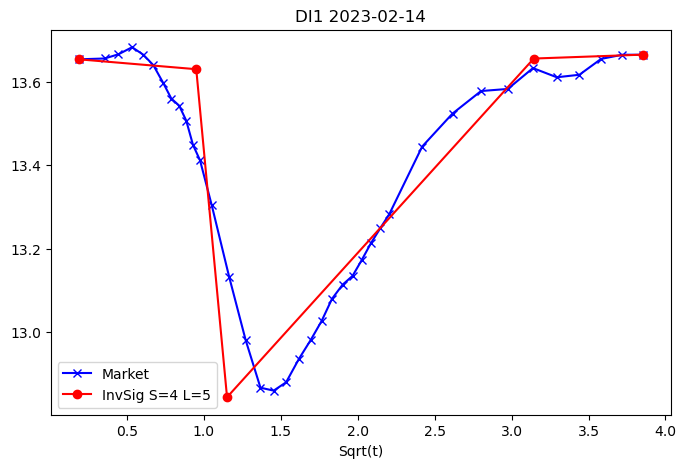

In [462]:
plot_DI1_Inv_S4L5('2023-02-14', x0=[ 0.25, 0., 1., -1., 1.5, 0.5, 1.0, 0.])

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


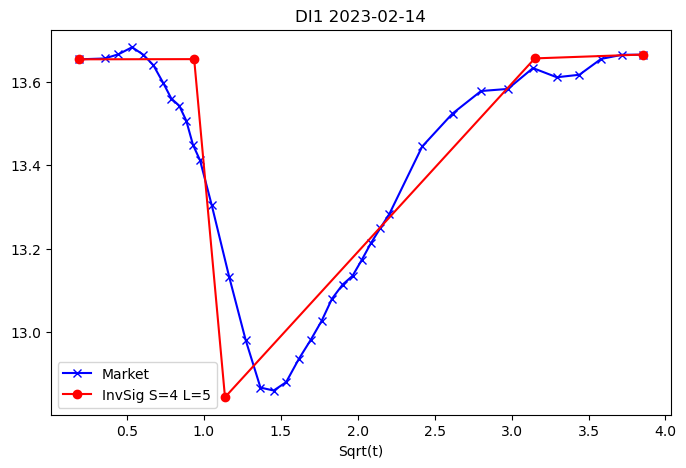

In [499]:
plot_DI1_Inv_S4L5_TC('2023-02-14', x0=[ 0.25, 0., 1., -1., 1.5, 0.5, 1.0, 0.])

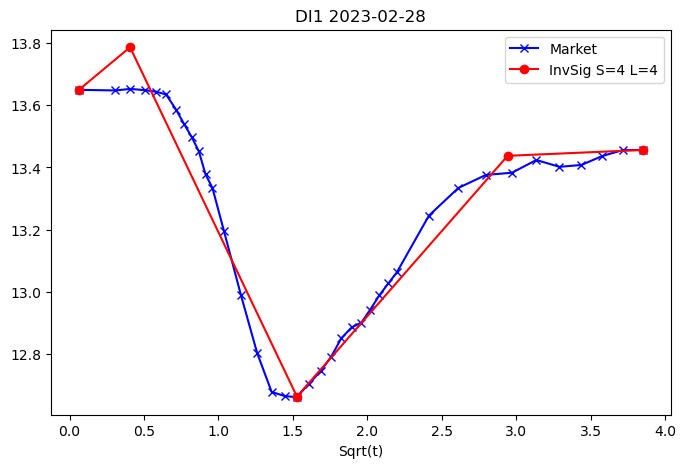

In [441]:
plot_DI1_Inv_S4L4('2023-02-28')

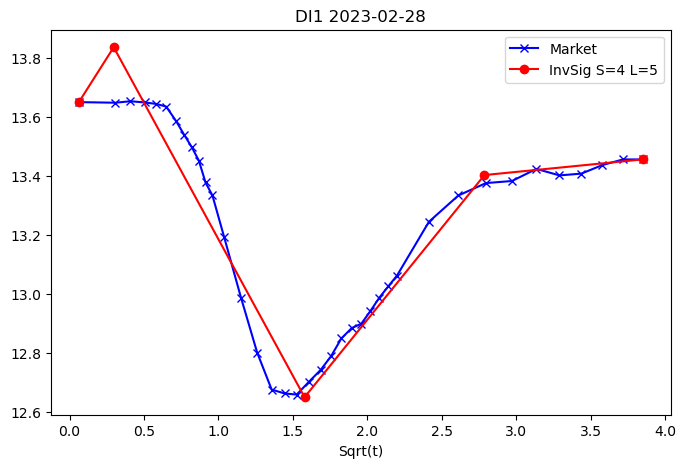

In [463]:
plot_DI1_Inv_S4L5('2023-02-28')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


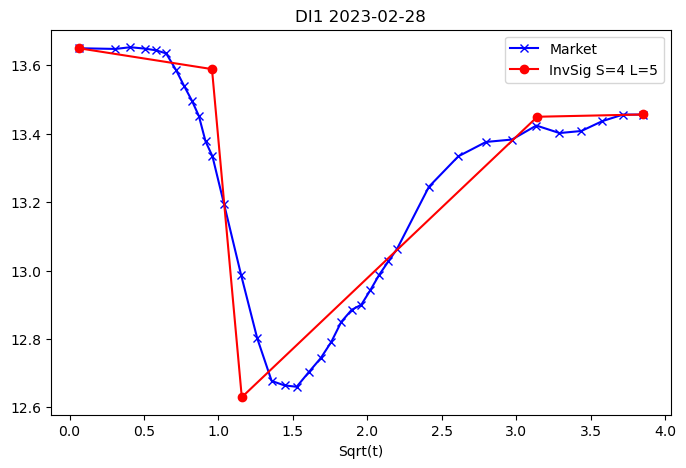

In [500]:
plot_DI1_Inv_S4L5_TC('2023-02-28')

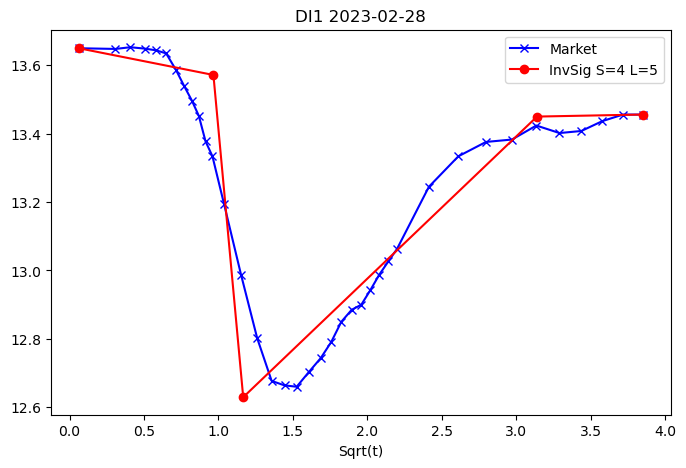

In [464]:
plot_DI1_Inv_G_S4L5('2023-02-28')

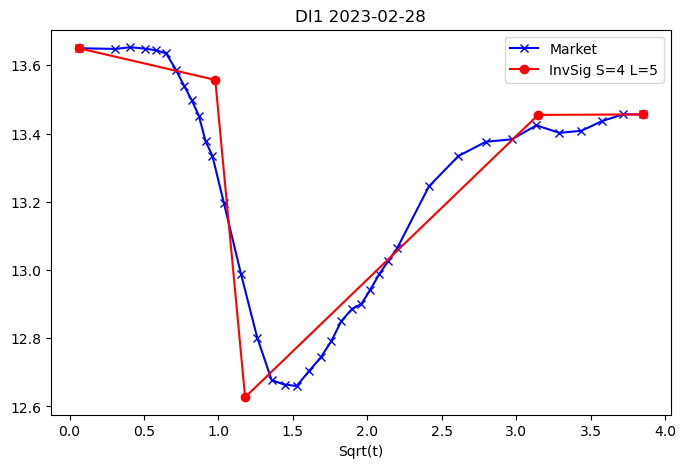

In [452]:
plot_DI1_Inv_G_S4L5('2023-02-28', weights=[50, 10, 10, 10, 10, 10, 10, 10, 0, 0, 0, 0, 0, 0])

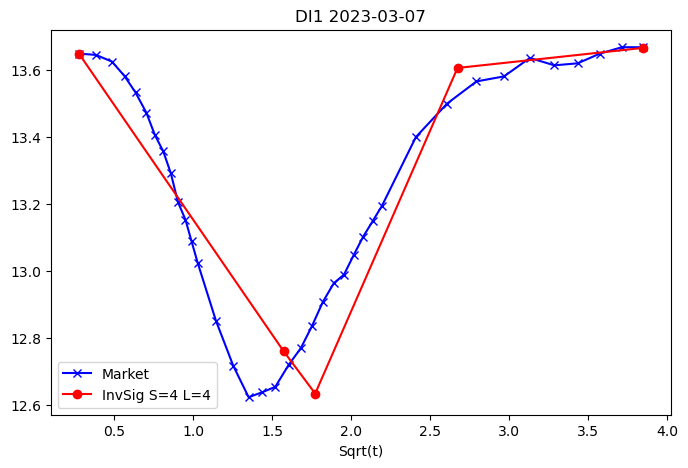

In [444]:
plot_DI1_Inv_S4L4('2023-03-07')

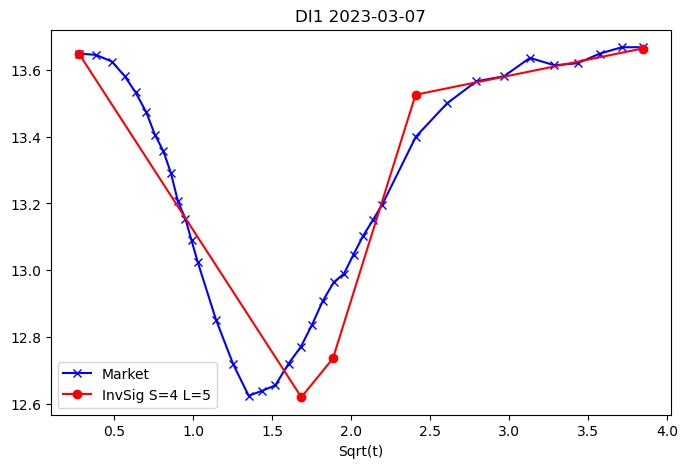

In [445]:
plot_DI1_Inv_S4L5('2023-03-07')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


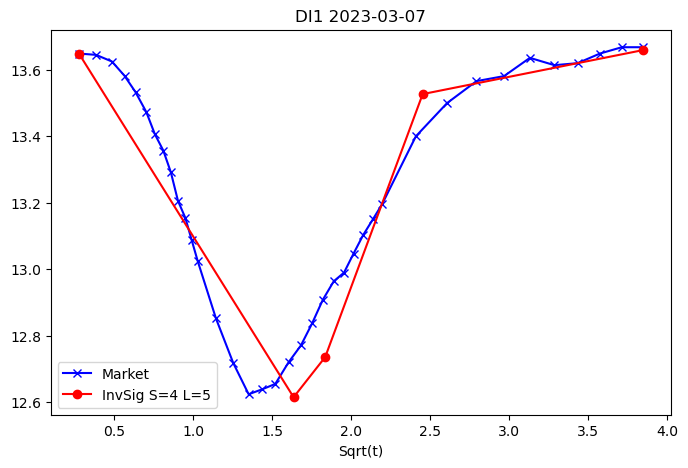

In [501]:
plot_DI1_Inv_S4L5_TC('2023-03-07')

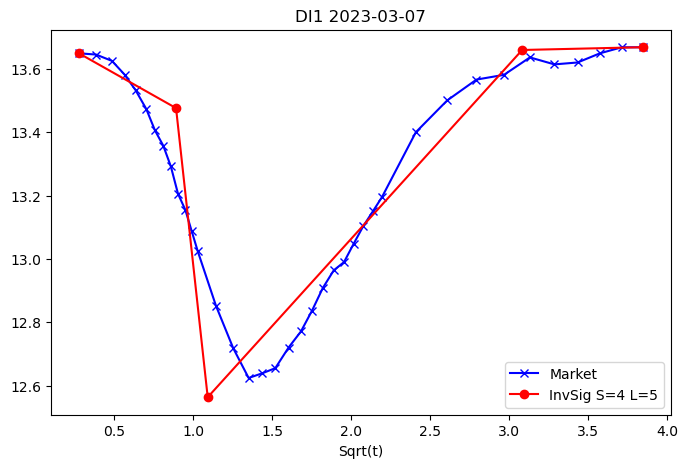

In [446]:
plot_DI1_Inv_G_S4L5('2023-03-07')

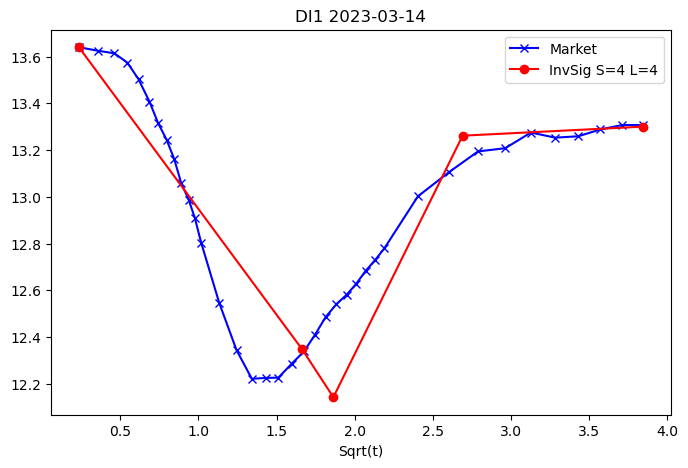

In [447]:
plot_DI1_Inv_S4L4('2023-03-14')

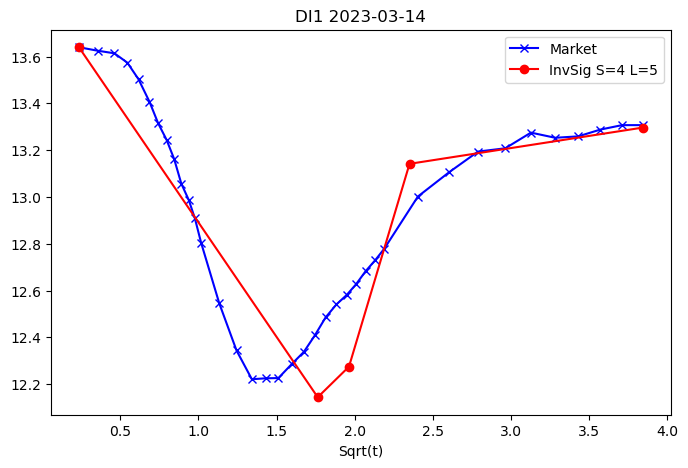

In [448]:
plot_DI1_Inv_S4L5('2023-03-14')

/opt/miniconda3/envs/pyenv/lib/python3.11/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


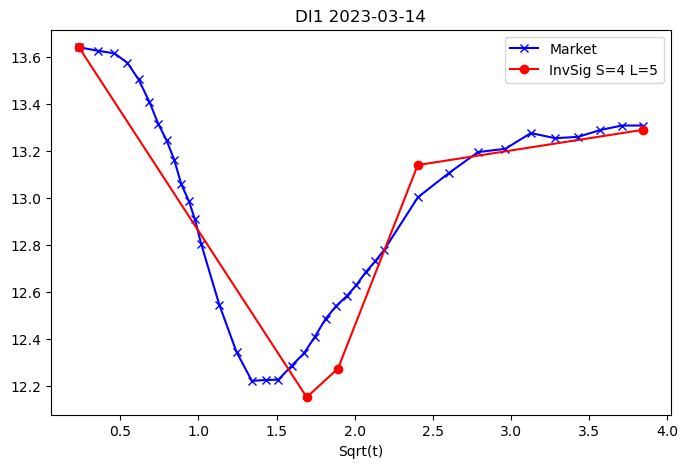

In [502]:
plot_DI1_Inv_S4L5_TC('2023-03-14')

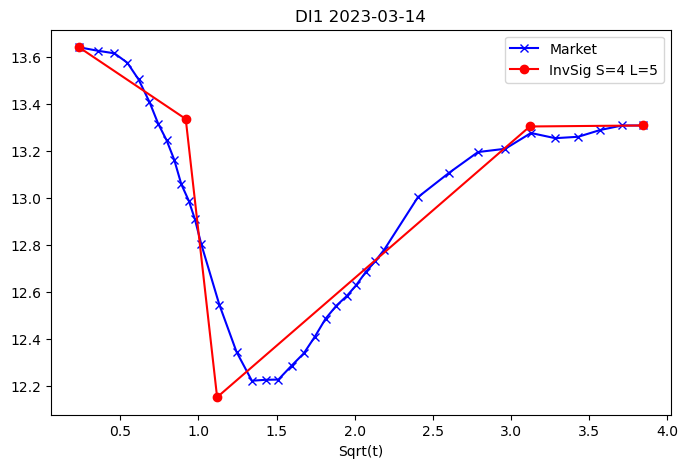

In [449]:
plot_DI1_Inv_G_S4L5('2023-03-14')